In [2]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.stats import gaussian_kde

from wilco_holm import draw_cd_diagram

import sys
os.chdir('C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm')

# Use the current working directory as the base path
sys.path.append(os.path.abspath(os.path.join('C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests', '..','..')))

from ml_edm.classification.classifiers_collection import ClassifiersCollection
from ml_edm.utils import check_timestamps 
from ml_edm.early_classifier import EarlyClassifier
from ml_edm.cost_matrices import CostMatrices
from ml_edm.trigger import *

In [6]:
# generate confidence intervals for each approach
from scipy.stats import bootstrap
def get_confidence_interval(ranks_array):
    ci_lower = [ranks_array[0][0]]
    ci_upper = [ranks_array[0][0]]

    for rank in ranks_array[1:]:
        try : 
            res = bootstrap((rank,), np.mean, confidence_level=0.9)
            ci_lower.append(res.confidence_interval.low)
            ci_upper.append(res.confidence_interval.high)
        except Exception as e:
            print(f"Error calculating confidence interval: {e}")
            ci_lower.append(rank[0])
            ci_upper.append(rank[0])
    return ci_lower, ci_upper

### Use predictions out of collection and no additional flattening and train loader is built with the flattened costs and start val epoch 0

In [37]:
json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\metrics_all_non_z_norm_unb_exp_delay.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    metrics = json.load(file)



json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\metrics_target_flatten_one_reg_val_model_selection_unb_exp_delay_collection.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    metrics_one_reg = json.load(file)

In [39]:
def plot_ranks(metrics_one_reg,metrics):
    datasets = ['BME','GunPointAgeSpan','DodgerLoopDay','Chinatown','ChilledWaterPredictor','SmoothSubspace','HotwaterPredictor','TetuanEnergyConsumption','AcousticContaminationMadrid_nmv','UMD']
    alphas = ['0.0' , '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '1.0']

    metrics_one_reg['CALIMERA']={alpha: {dataset: None for dataset in datasets} for alpha in alphas}
    metrics_one_reg['CALIMERA_eps']={alpha: {dataset: None for dataset in datasets} for alpha in alphas}

    for alpha in alphas :
        for dataset in datasets :
            metrics_one_reg['CALIMERA'][alpha][dataset]=metrics['CALIMERA'][alpha][dataset]
            metrics_one_reg['CALIMERA_eps'][alpha][dataset]=metrics['CALIMERA_eps'][alpha][dataset]

    data = []
    for trigger, alphas in metrics_one_reg.items():
        for alpha, datasets in alphas.items():
            for dataset, values in datasets.items():
                data.append({
                'Trigger': trigger,
                'Alpha': alpha,
                'Dataset': dataset,
                'Average Cost': values['average_cost']
                
            })

# Create a DataFrame
    df = pd.DataFrame(data)

# Pivot the DataFrame to get triggers as columns
    pivot_df = df.pivot_table(index=['Alpha', 'Dataset'], columns='Trigger', values='Average Cost')

# Reset index to flatten the DataFrame
    pivot_df.reset_index(inplace=True)




# for each row rank the triggers
    ranked_df = pivot_df.copy()
    ranked_df.iloc[:, 2:] = ranked_df.iloc[:, 2:].rank(axis=1, method='average', ascending=True)

    ranked_df.columns = ['Alpha', 'Dataset'] + [f'Rank {col}' for col in ranked_df.columns[2:]]

    ranks_calimera = ranked_df.groupby('Alpha')['Rank CALIMERA']
    ranks_calimera_eps = ranked_df.groupby('Alpha')['Rank CALIMERA_eps']

    ranks_calimera_one_reg = ranked_df.groupby('Alpha')['Rank CALIMERA_one_reg']

    ranks_calimera_mean = ranks_calimera.mean()
    ranks_calimera_eps_mean = ranks_calimera_eps.mean()



    ranks_calimera_one_reg_mean = ranks_calimera_one_reg.mean()




    ranks_calimera_array = ranks_calimera.apply(list).to_numpy()


    ci_lower_cal, ci_upper_cal = get_confidence_interval(ranks_calimera_array)


    alphas = np.array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])
# plot the mean w.r.t alphas for each trigger
    plt.figure(figsize=(14, 6))
    plt.plot(alphas, ranks_calimera_mean, label='CALIMERA', marker='o')
    plt.fill_between(alphas, ci_lower_cal,ci_upper_cal, alpha=.2)

    plt.plot(alphas, ranks_calimera_one_reg_mean, label='CALIMERA_one_reg', marker='<')
    plt.plot(alphas, ranks_calimera_eps_mean, label='CALIMERA_eps', marker='s')
    plt.xlabel('Alphas')
    plt.ylabel('Mean ranks')
    plt.title('Mean ranks vs Alpha Platt Scaling Non-Z norm Unb MisClf Cost Exponential Delay')
    plt.legend()
    plt.grid()
    plt.show()
    return pivot_df


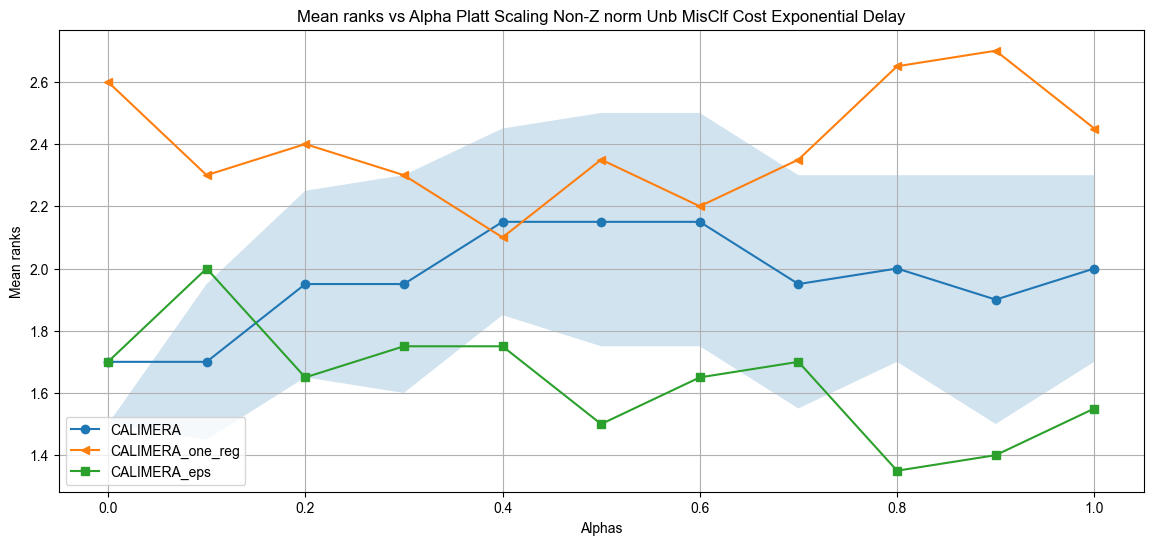

Trigger,Alpha,Dataset,CALIMERA,CALIMERA_eps,CALIMERA_one_reg
0,0.0,AcousticContaminationMadrid_nmv,1.254961,1.254961,1.269426
1,0.0,BME,1.240938,1.240938,1.240938
2,0.0,ChilledWaterPredictor,1.245197,1.245197,2.193421
3,0.0,Chinatown,1.211528,1.211528,2.563923
4,0.0,DodgerLoopDay,1.250899,1.250899,1.328978
...,...,...,...,...,...
105,1.0,GunPointAgeSpan,6.097561,4.878049,6.097561
106,1.0,HotwaterPredictor,8.537736,7.603774,8.518868
107,1.0,SmoothSubspace,2.805556,2.805556,2.777778
108,1.0,TetuanEnergyConsumption,17.318182,16.445455,19.100000


In [40]:

plot_ranks(metrics_one_reg,metrics)

### Use predictions out of collection and no additional flattening and train loader is built with the original costs and start val epoch 0

In [41]:
json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\metrics_all_non_z_norm_unb_exp_delay.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    metrics = json.load(file)



json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\metrics_target_flatten_one_reg_val_model_selection_unb_exp_delay_collection_2.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    metrics_one_reg = json.load(file)

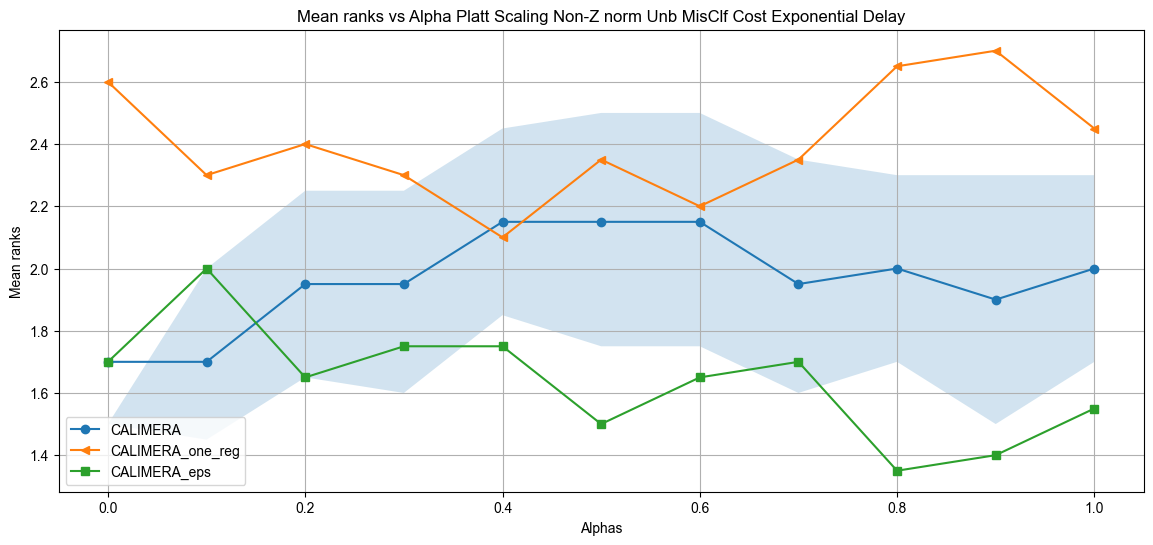

Trigger,Alpha,Dataset,CALIMERA,CALIMERA_eps,CALIMERA_one_reg
0,0.0,AcousticContaminationMadrid_nmv,1.254961,1.254961,1.269426
1,0.0,BME,1.240938,1.240938,1.240938
2,0.0,ChilledWaterPredictor,1.245197,1.245197,2.193421
3,0.0,Chinatown,1.211528,1.211528,2.563923
4,0.0,DodgerLoopDay,1.250899,1.250899,1.328978
...,...,...,...,...,...
105,1.0,GunPointAgeSpan,6.097561,4.878049,6.097561
106,1.0,HotwaterPredictor,8.537736,7.603774,8.518868
107,1.0,SmoothSubspace,2.805556,2.805556,2.777778
108,1.0,TetuanEnergyConsumption,17.318182,16.445455,19.100000


In [42]:
plot_ranks(metrics_one_reg,metrics)

### Using predictions output of collection as targets ( without additional flattening) start eval epoch at 20 and train loader is built with original costs

In [43]:
json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\metrics_all_non_z_norm_unb_exp_delay.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    metrics = json.load(file)



json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\metrics_target_flatten_one_reg_val_model_selection_unb_exp_delay_collection_3.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    metrics_one_reg = json.load(file)

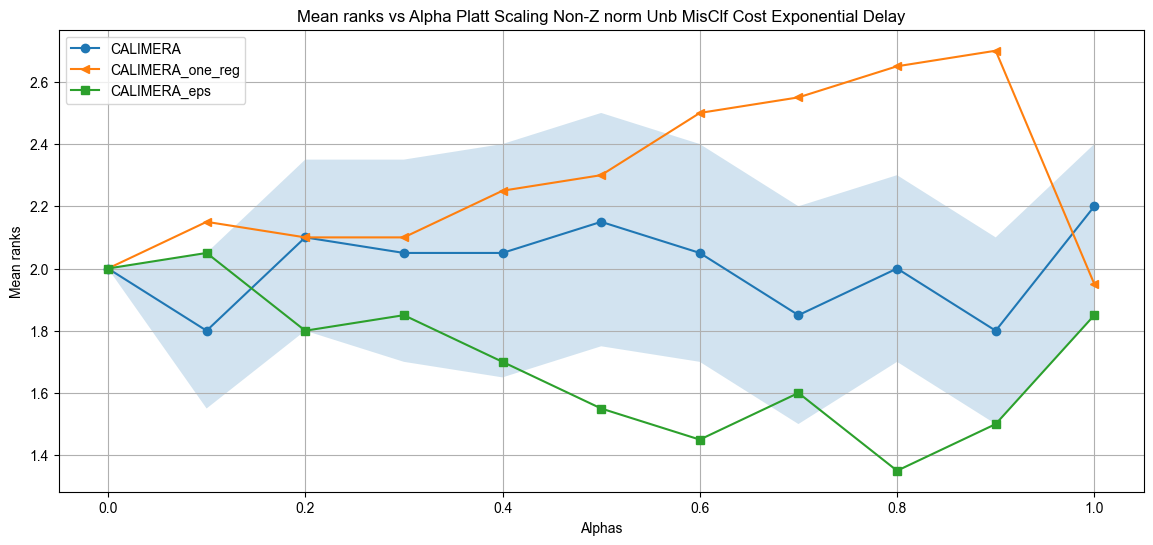

In [44]:
pivot_df=plot_ranks(metrics_one_reg,metrics)

In [16]:
pivot_df[pivot_df['Alpha']=='0.1']

Trigger,Alpha,Dataset,CALIMERA,CALIMERA_one_reg,CALIMERA_true_target
10,0.1,AcousticContaminationMadrid_nmv,3.345336,3.212798,3.481560
11,0.1,BME,1.426843,2.978208,1.426843
12,0.1,ChilledWaterPredictor,2.703285,2.722127,2.959258
13,0.1,Chinatown,1.197902,1.197902,1.197902
14,0.1,DodgerLoopDay,2.234142,2.234142,2.240027
15,0.1,GunPointAgeSpan,1.997114,2.823090,2.007288
16,0.1,HotwaterPredictor,2.071766,2.256526,2.221395
17,0.1,SmoothSubspace,2.923421,2.923421,2.923421
18,0.1,TetuanEnergyConsumption,3.125809,3.125809,3.125809
19,0.1,UMD,3.168381,2.983955,3.168381


### Using predictions output of collection as targets  with additional flattening start eval epoch at 20 and train loader is built with original costs

In [45]:
json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\metrics_all_non_z_norm_unb_exp_delay.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    metrics = json.load(file)




json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\metrics_target_flatten_one_reg_val_model_selection_unb_exp_delay_collection_4.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    metrics_one_reg = json.load(file)

C:\Users\WTHK0243\AppData\Roaming\Python\Python310\site-packages\scipy\stats\_resampling.py:100: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  warnings.warn(DegenerateDataWarning(msg))


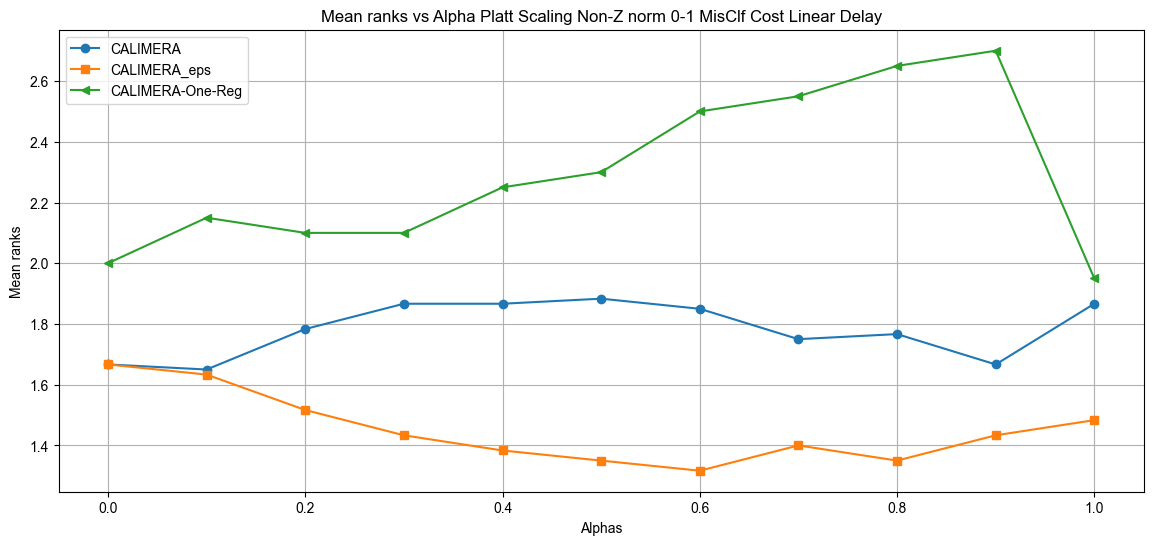

In [46]:
pivot_df=plot_ranks_eps(metrics_one_reg,metrics)

## Using predictions output of collection as targets  with additional flattening start eval epoch at 20 and train loader is built with original costs and use mask during training

In [5]:
json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\metrics_target_flatten_one_reg_val_model_selection_unb_exp_delay_full_loss_mask_1000.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    metrics = json.load(file)


json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\metrics_target_flatten_one_reg_val_model_selection_unb_exp_delay_collection_5.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    metrics_one_reg = json.load(file)

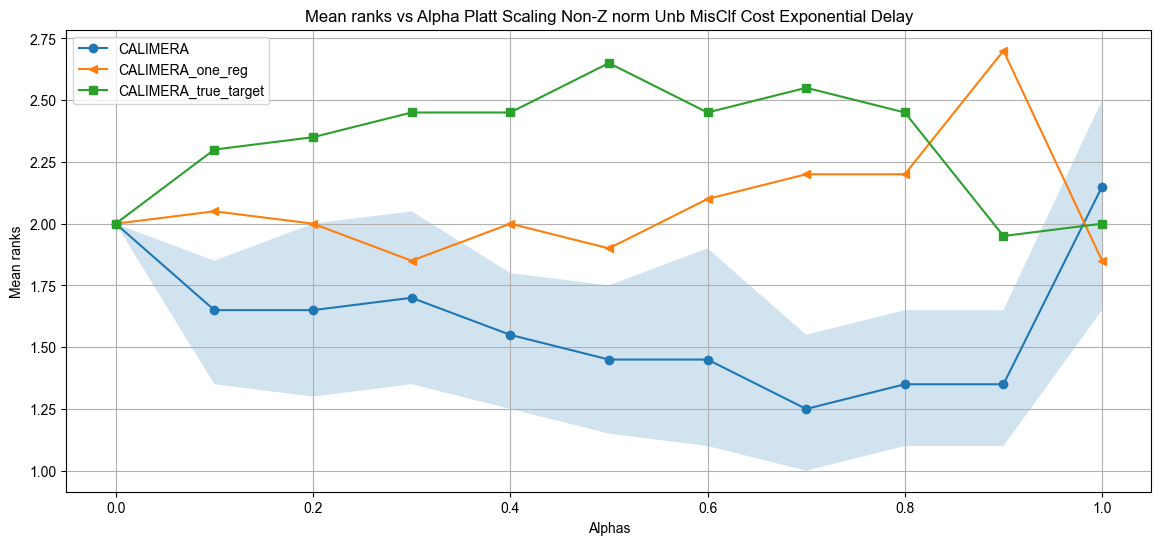

In [6]:
pivot_df=plot_ranks(metrics_one_reg,metrics)

In [7]:
pivot_df[pivot_df['Alpha']=='0.8']

Trigger,Alpha,Dataset,CALIMERA,CALIMERA_one_reg,CALIMERA_true_target
80,0.8,AcousticContaminationMadrid_nmv,15.950850,16.917659,19.785327
81,0.8,BME,0.829251,15.139097,0.855285
82,0.8,ChilledWaterPredictor,11.675034,13.067529,19.455919
83,0.8,Chinatown,0.831634,1.102521,1.961025
84,0.8,DodgerLoopDay,9.212950,9.116846,9.212950
85,0.8,GunPointAgeSpan,4.645674,6.658613,5.132554
86,0.8,HotwaterPredictor,9.011658,9.335832,10.942661
87,0.8,SmoothSubspace,9.664633,22.222222,7.816867
88,0.8,TetuanEnergyConsumption,16.054939,15.781859,18.583551
89,0.8,UMD,8.684933,20.000000,10.992367


### Using predictions output of collection as targets and full train and mask mechanism and select last model

In [50]:
json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\metrics_all_non_z_norm_unb_exp_delay.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    metrics = json.load(file)



json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\metrics_target_flatten_one_reg_val_model_selection_unb_exp_delay_collection_6.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    metrics_one_reg = json.load(file)

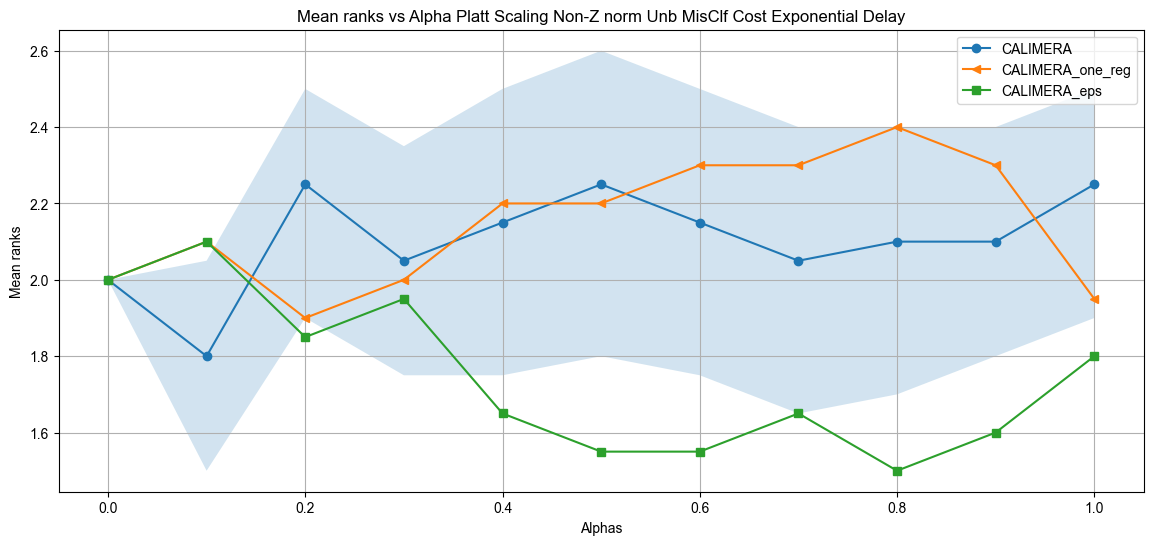

In [51]:
pivot_df=plot_ranks(metrics_one_reg,metrics)

In [29]:
def plot_histograms_lower_than_last(avg_cost_test, trigger='CALIMERA_one_reg'):
    

    percentages = {}
    for alpha, datasets in avg_cost_test[trigger].items():
        alpha_percentages = []
        for dataset, values in datasets.items():
            if len(values) < 2:
                continue
            last_val = values[-1]
            count_lower = sum(v <= last_val for v in values[:-1])
            percent = 100 * count_lower / (len(values) - 1)
            alpha_percentages.append(percent)
        percentages[alpha] = alpha_percentages

    n_alphas = len(percentages)

    # Split the plots into multiple rows for better readability
    n_cols = 4
    n_rows = int(np.ceil(n_alphas / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows), sharey=True)
    axes = axes.flatten()
    for idx, (alpha, vals) in enumerate(percentages.items()):
        axes[idx].hist(vals, bins=10, range=(0, 100), alpha=0.7)
        axes[idx].set_title(f'Alpha {alpha}')
        axes[idx].set_xlabel('% lower than last')
        axes[idx].set_ylabel('Datasets')
        axes[idx].set_xlim(0, 100)
    # Hide unused subplots
    for ax in axes[len(percentages):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

In [52]:
pivot_df[pivot_df['Alpha']=='0.5']

Trigger,Alpha,Dataset,CALIMERA,CALIMERA_eps,CALIMERA_one_reg
50,0.5,AcousticContaminationMadrid_nmv,10.710458,10.563322,11.173338
51,0.5,BME,1.148578,0.974509,0.997299
52,0.5,ChilledWaterPredictor,8.081316,7.324061,8.591662
53,0.5,Chinatown,1.227471,1.146154,0.818905
54,0.5,DodgerLoopDay,6.344874,6.344874,6.285056
55,0.5,GunPointAgeSpan,3.066020,3.296524,3.926711
56,0.5,HotwaterPredictor,5.250543,4.028542,5.540712
57,0.5,SmoothSubspace,9.370127,9.179678,9.349525
58,0.5,TetuanEnergyConsumption,10.715324,10.625449,10.692499
59,0.5,UMD,6.342930,7.982434,7.215639


In [37]:

json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\avg_val_one_reg_target_flatten_val_model_selection_unb_exp_delay_collection_6.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    avg_val = json.load(file)



json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\avg_test_one_reg_target_flatten_val_model_selection_unb_exp_delay_collection_6.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    avg_test = json.load(file)
json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\val_losses_one_reg_target_flatten_val_model_selection_unb_exp_delay_collection_6.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    val_losses = json.load(file)
json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\train_losses_one_reg_target_flatten_val_model_selection_unb_exp_delay_collection_6.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    train_losses = json.load(file)

In [38]:
datasets = ['BME','GunPointAgeSpan','DodgerLoopDay','Chinatown','ChilledWaterPredictor','SmoothSubspace','HotwaterPredictor','TetuanEnergyConsumption','AcousticContaminationMadrid_nmv','UMD']

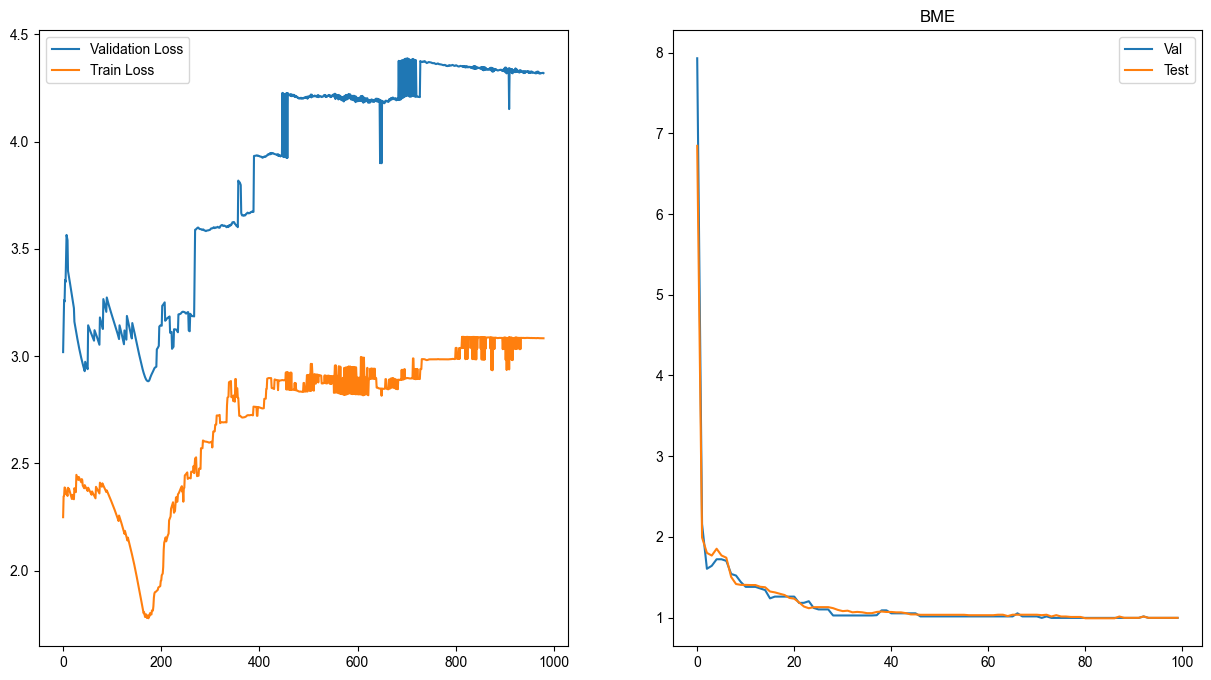

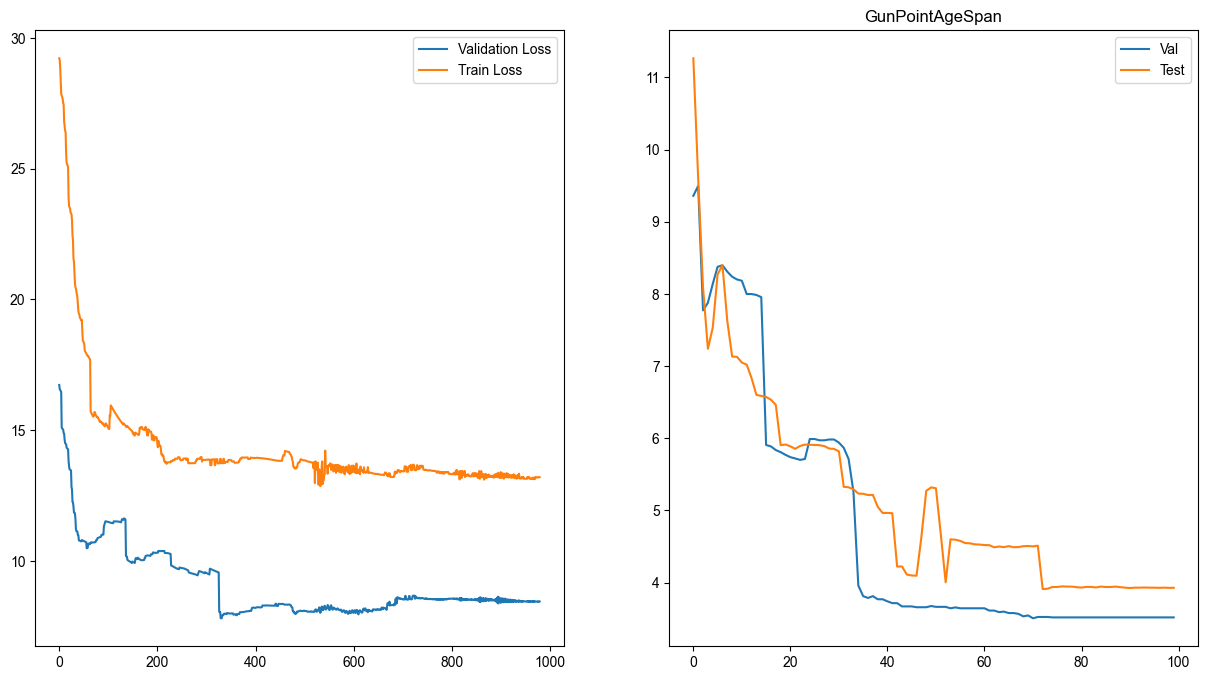

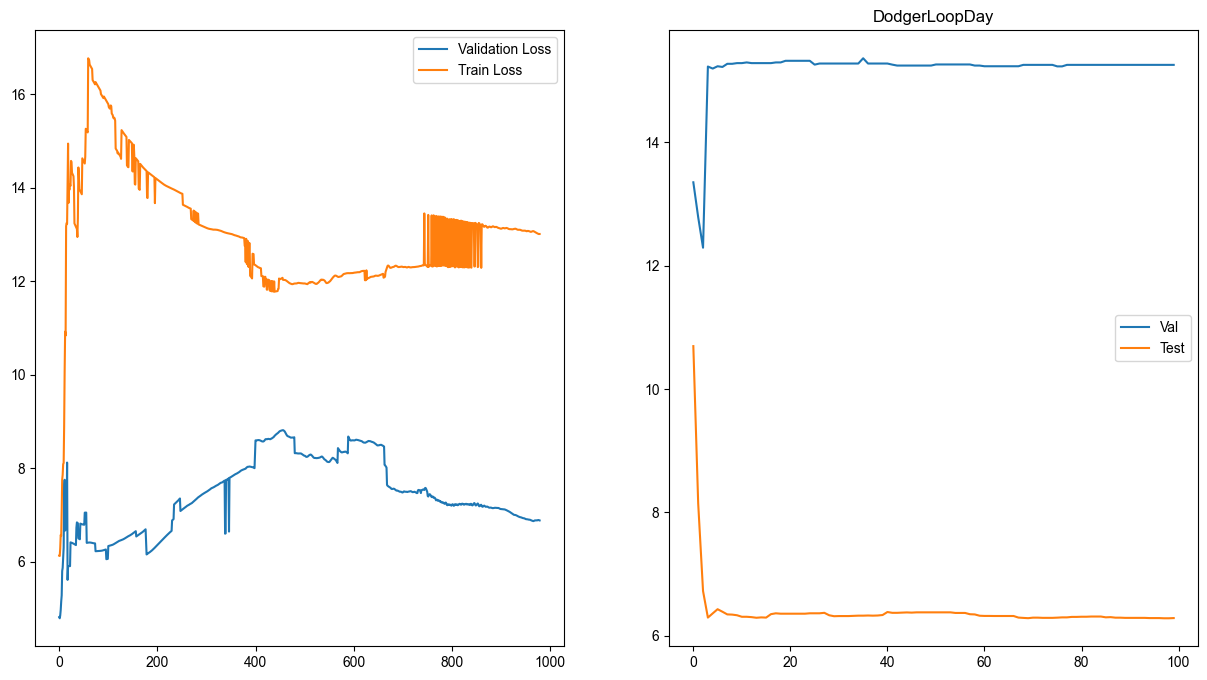

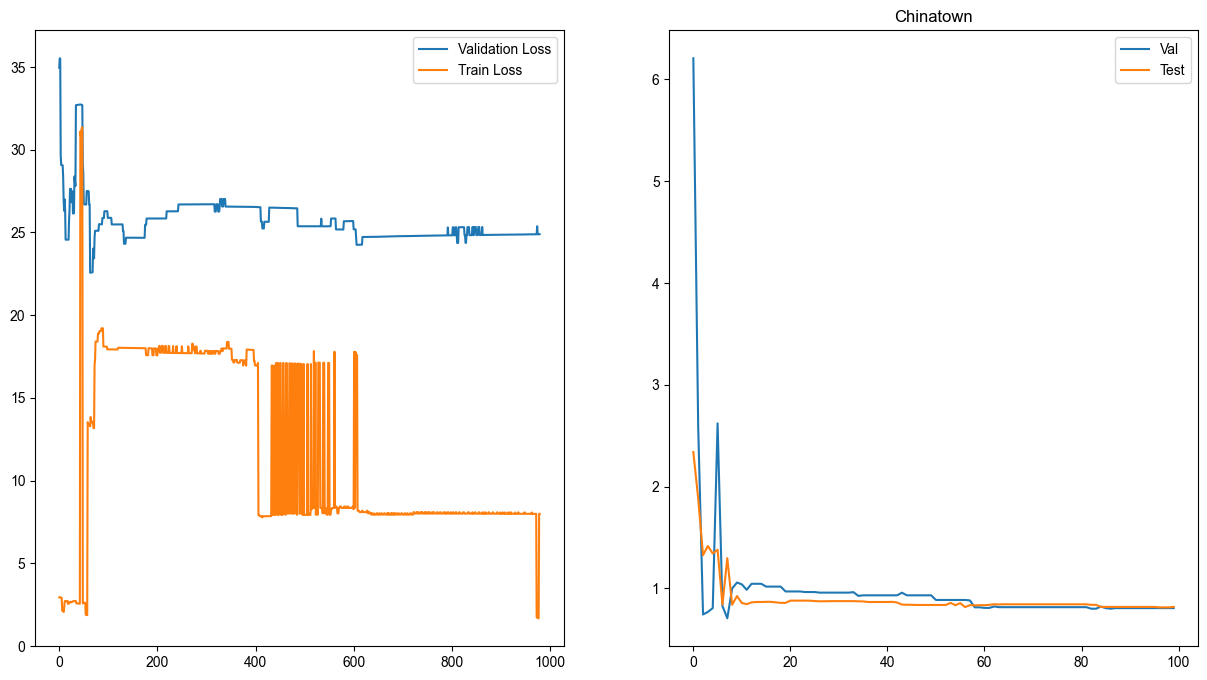

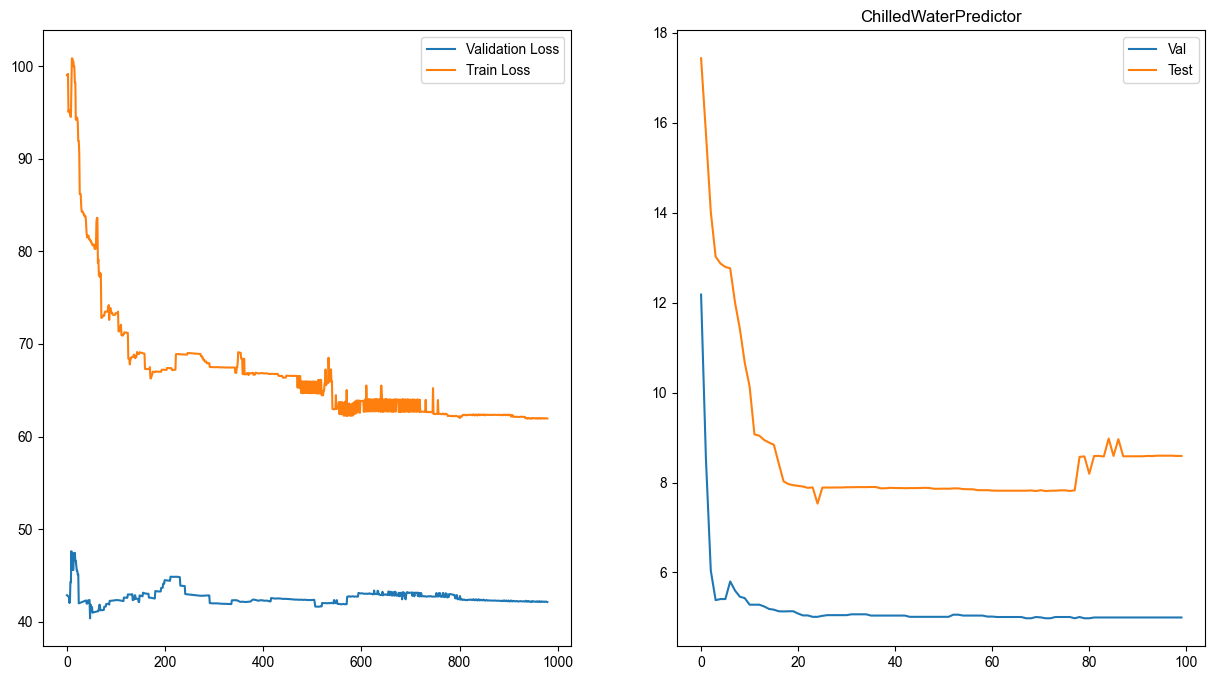

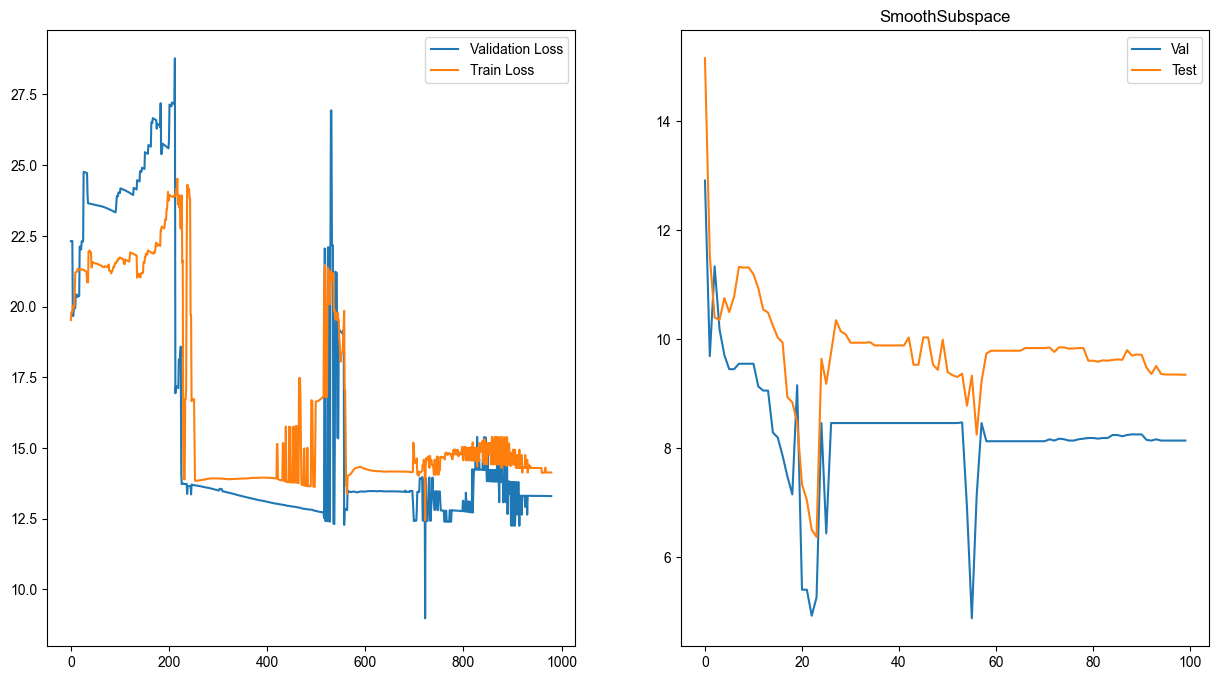

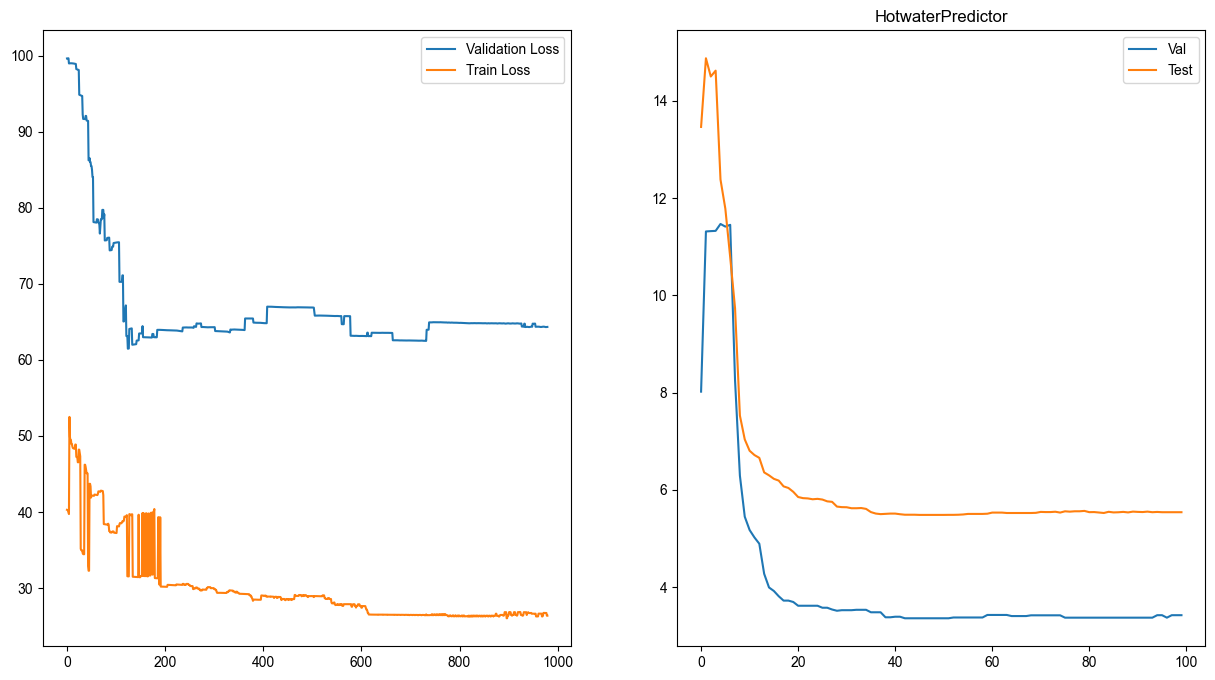

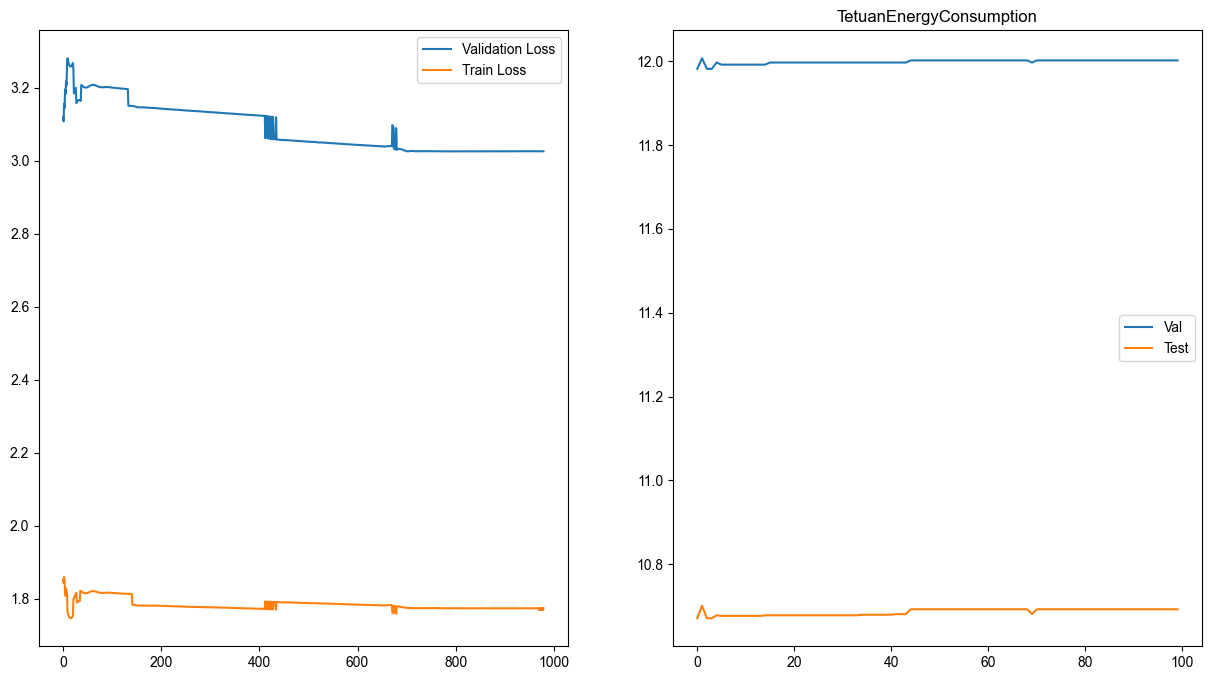

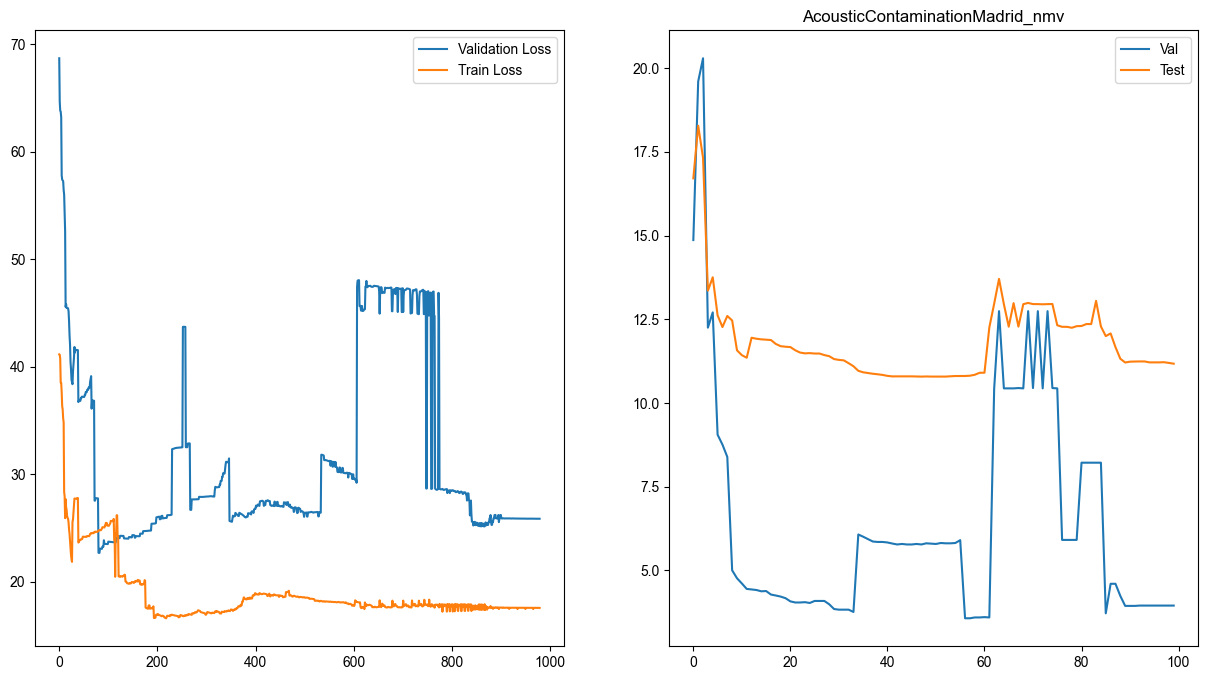

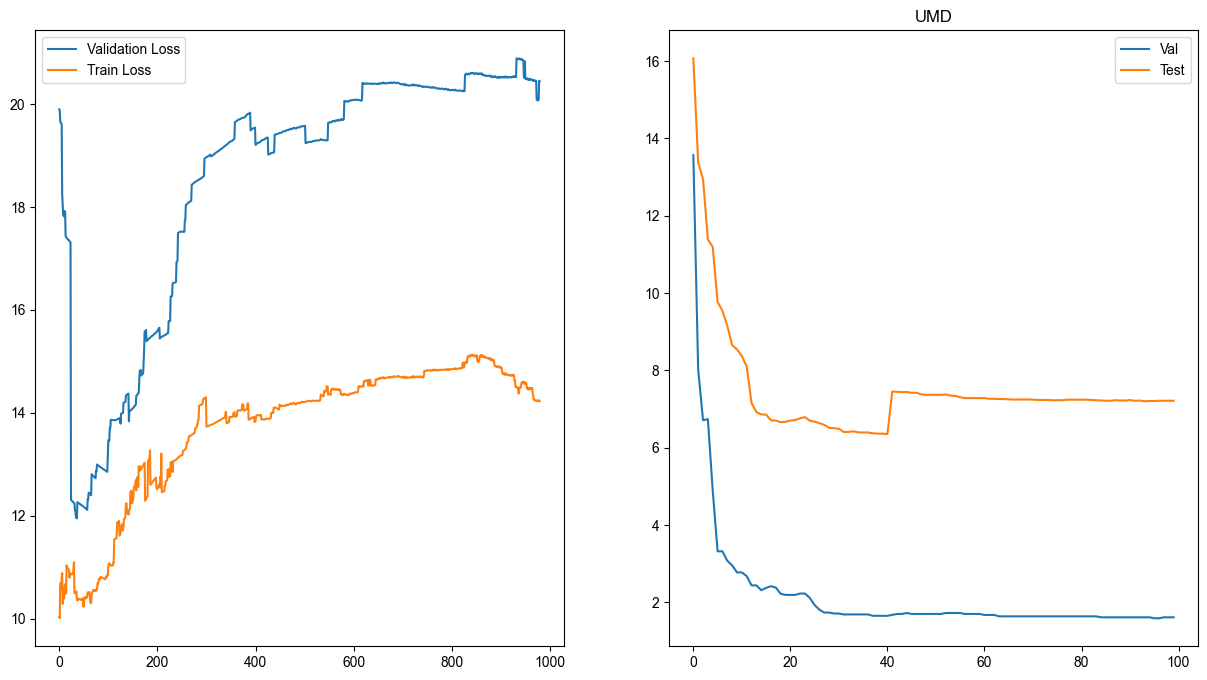

In [39]:
for dataset in datasets :
        fig, axes = plt.subplots(1,2,figsize=(15,8))
        
        
        axes[0].plot(val_losses['CALIMERA_one_reg']['0.5'][dataset], label='Validation Loss')
        axes[0].plot(train_losses['CALIMERA_one_reg']['0.5'][dataset], label='Train Loss')
        axes[0].legend()
       
        axes[1].plot(avg_val['CALIMERA_one_reg']['0.5'][dataset],label='Val')
        axes[1].plot(avg_test['CALIMERA_one_reg']['0.5'][dataset],label='Test')
        
        axes[1].legend()
        
        plt.title(f'{dataset}')

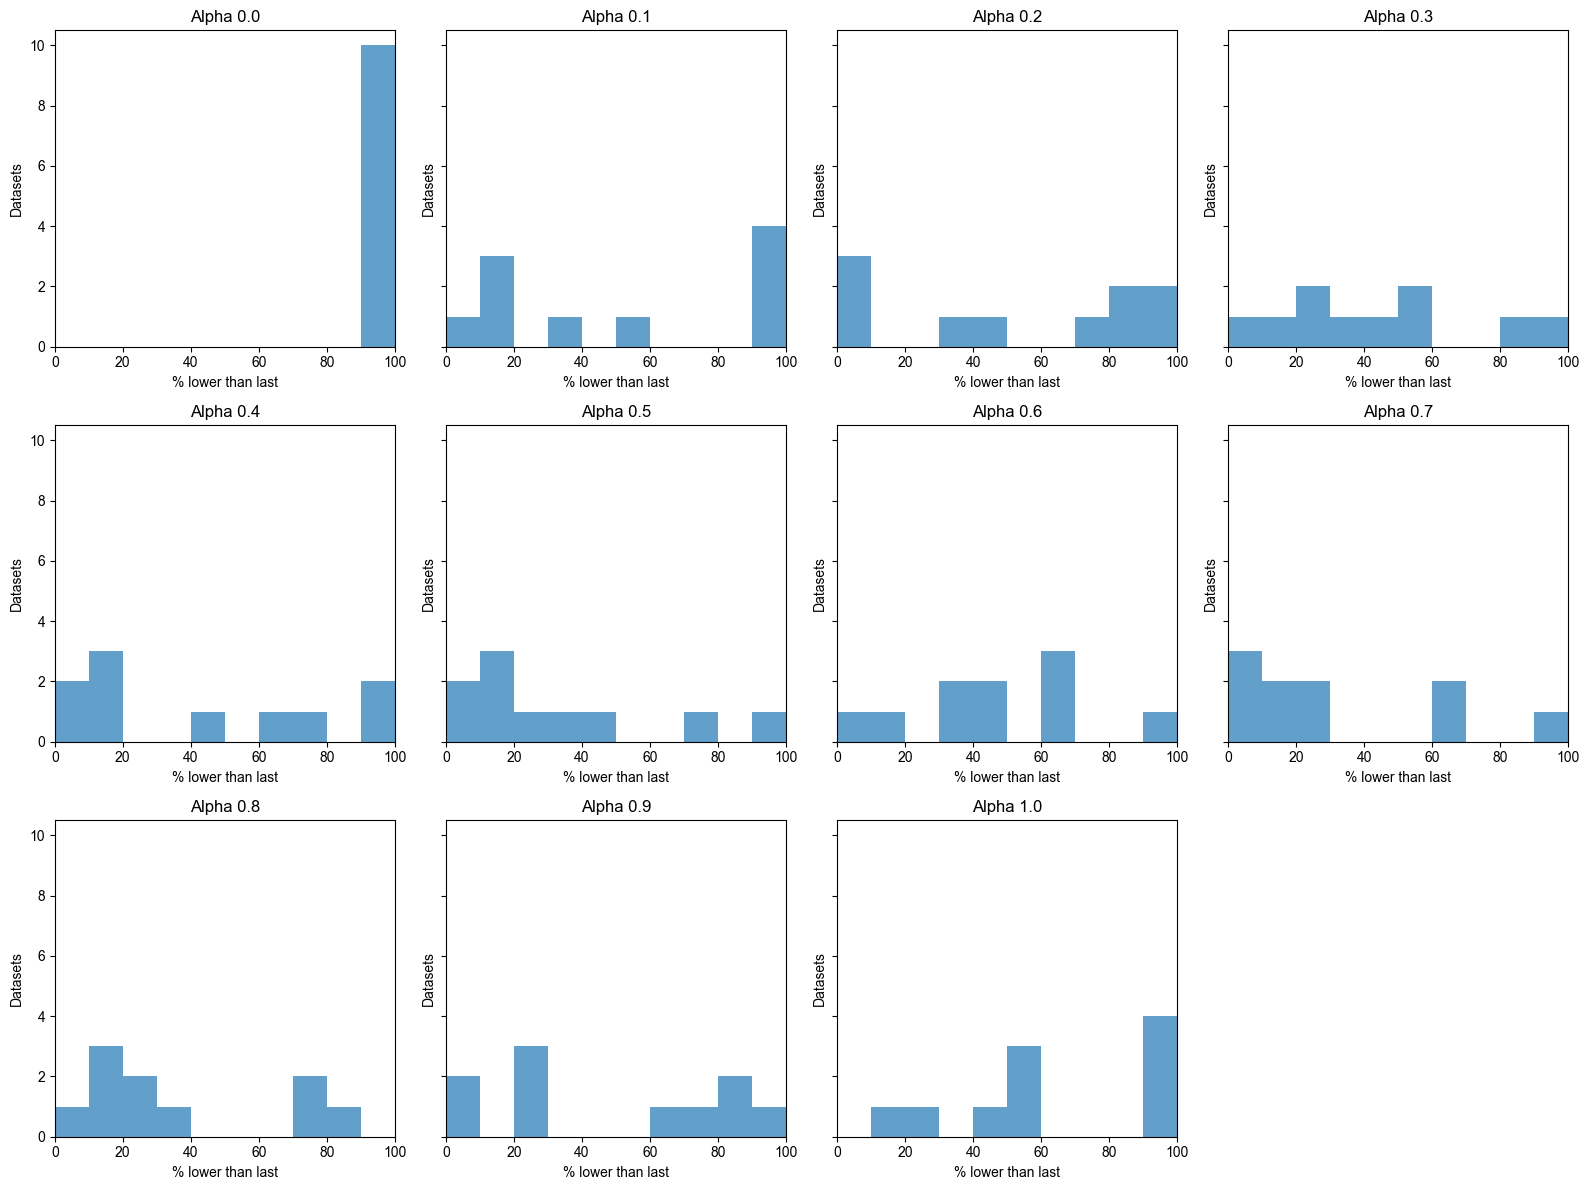

In [31]:
plot_histograms_lower_than_last(avg_test)

### Flatten target + masked loss + select last model

In [33]:
json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\metrics_all_non_z_norm_unb_exp_delay.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    metrics = json.load(file)


json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\metrics_target_flatten_one_reg_val_model_selection_unb_exp_delay_collection_7.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    metrics_one_reg = json.load(file)

C:\Users\WTHK0243\AppData\Roaming\Python\Python310\site-packages\scipy\stats\_resampling.py:100: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  warnings.warn(DegenerateDataWarning(msg))


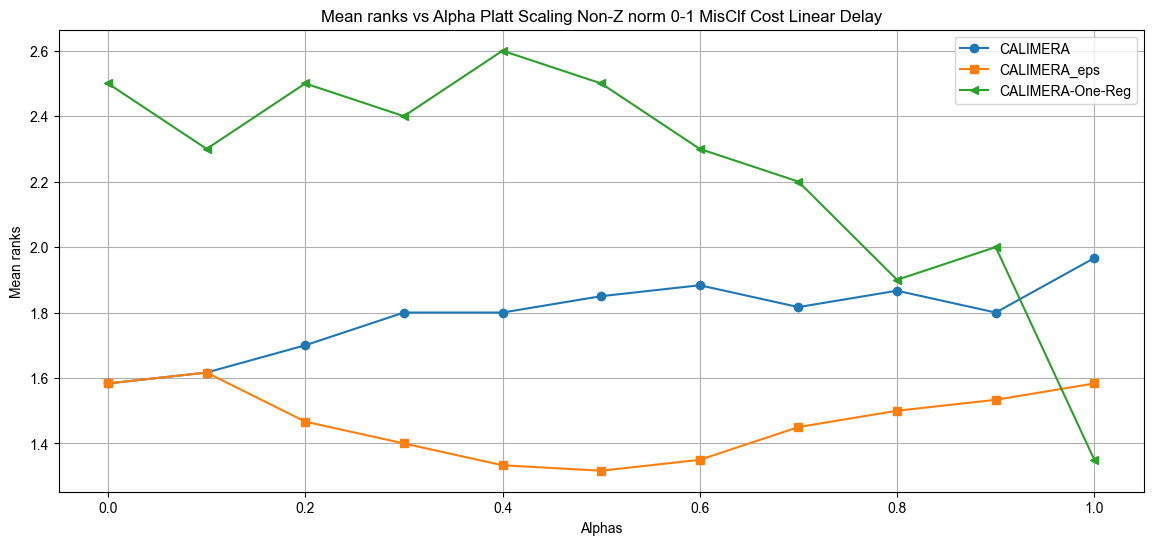

In [34]:
pivot_df=plot_ranks_eps(metrics_one_reg,metrics)

In [44]:
pivot_df[pivot_df['Alpha']=='0.5']

Trigger,Alpha,Dataset,CALIMERA,CALIMERA_one_reg,CALIMERA_true_target
50,0.5,AcousticContaminationMadrid_nmv,10.710458,12.235456,11.710337
51,0.5,BME,1.148578,1.307465,1.183660
52,0.5,ChilledWaterPredictor,8.081316,7.339723,12.143234
53,0.5,Chinatown,1.227471,1.546946,1.670690
54,0.5,DodgerLoopDay,6.344874,6.389526,6.344874
55,0.5,GunPointAgeSpan,3.066020,3.359872,4.114313
56,0.5,HotwaterPredictor,5.250543,4.872179,7.699164
57,0.5,SmoothSubspace,9.370127,8.016533,10.201460
58,0.5,TetuanEnergyConsumption,10.715324,12.878141,13.984339
59,0.5,UMD,6.342930,7.422977,7.577870


In [40]:

json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\avg_val_one_reg_target_flatten_val_model_selection_unb_exp_delay_collection_7.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    avg_val = json.load(file)



json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\avg_test_one_reg_target_flatten_val_model_selection_unb_exp_delay_collection_7.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    avg_test = json.load(file)
json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\val_losses_one_reg_target_flatten_val_model_selection_unb_exp_delay_collection_7.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    val_losses = json.load(file)
json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\train_losses_one_reg_target_flatten_val_model_selection_unb_exp_delay_collection_7.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    train_losses = json.load(file)

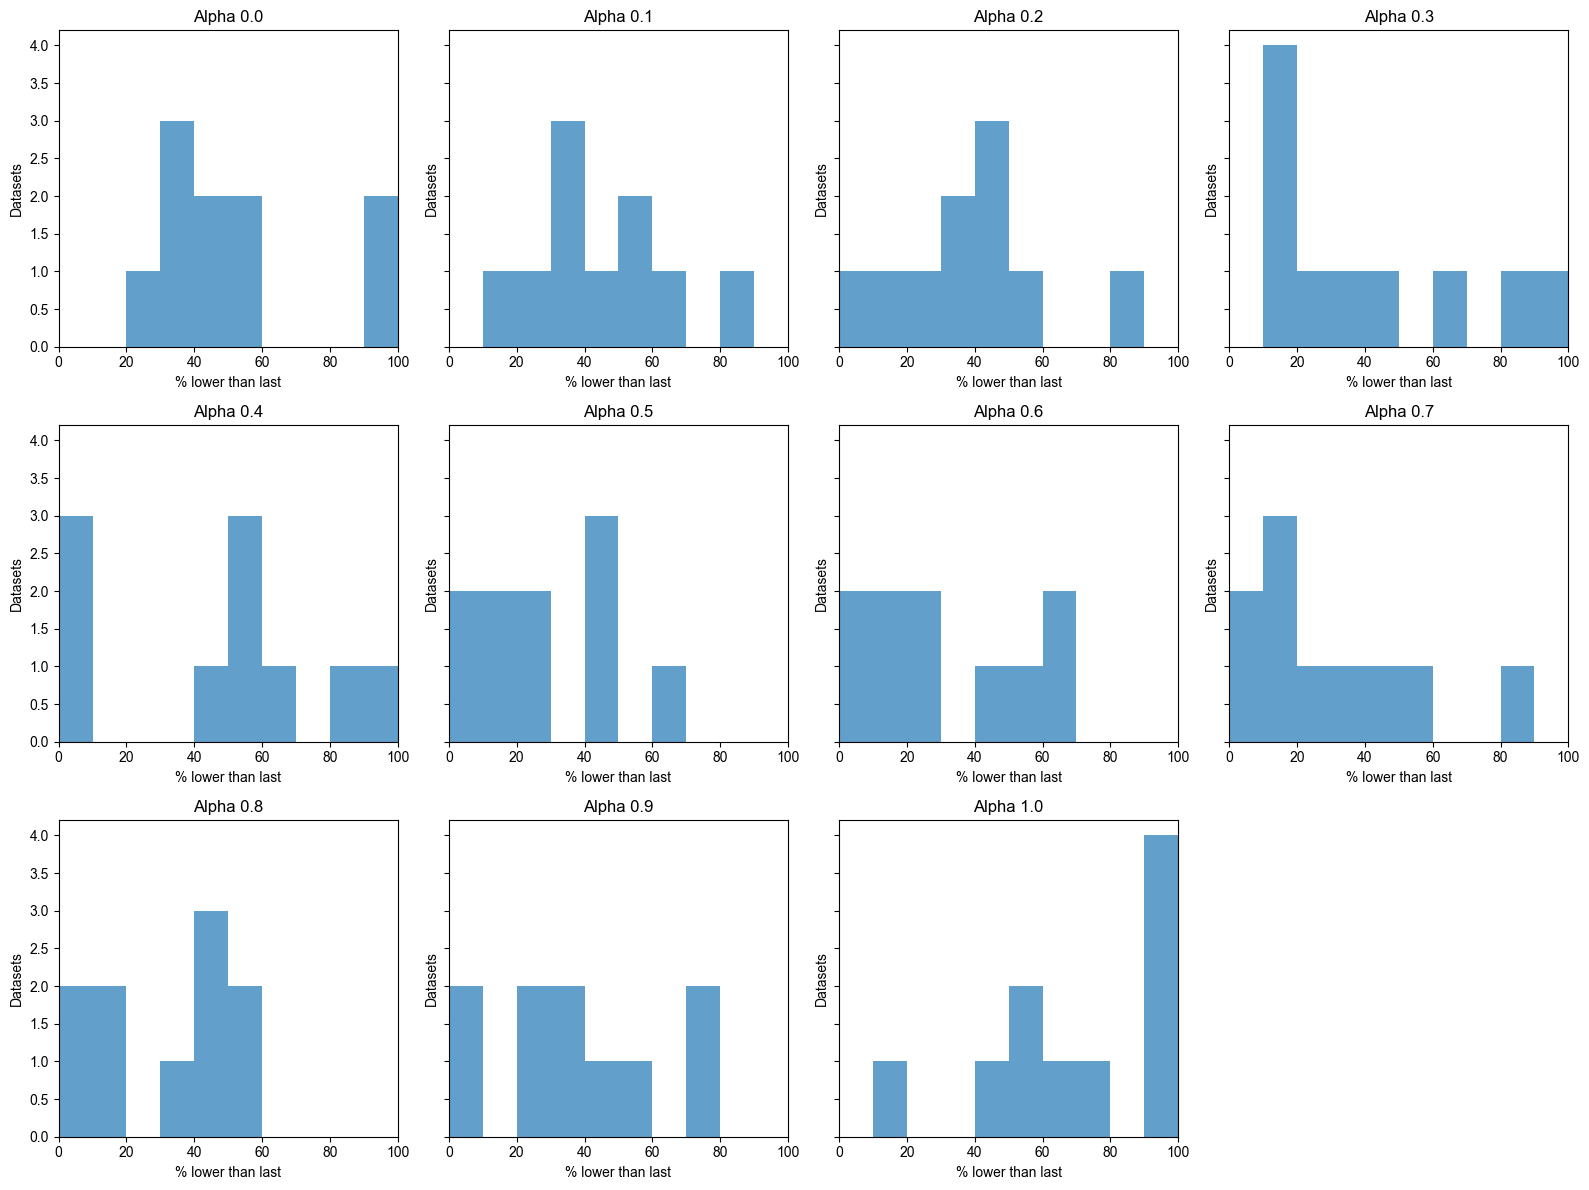

In [33]:
plot_histograms_lower_than_last(avg_test)

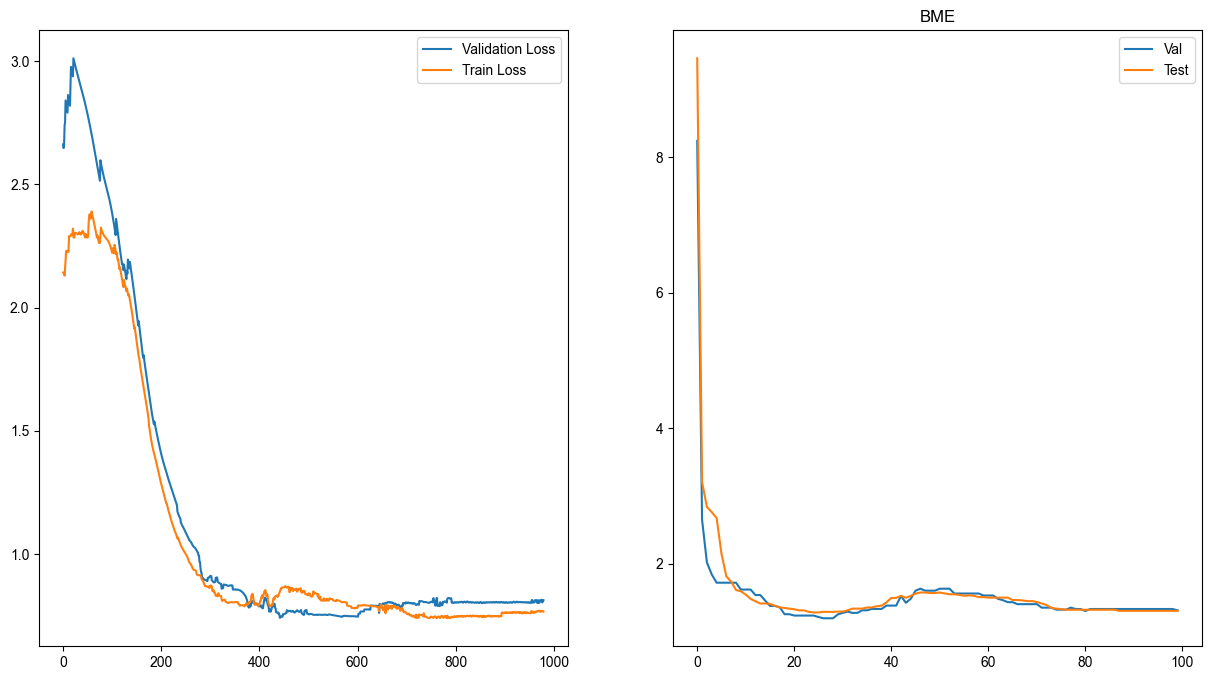

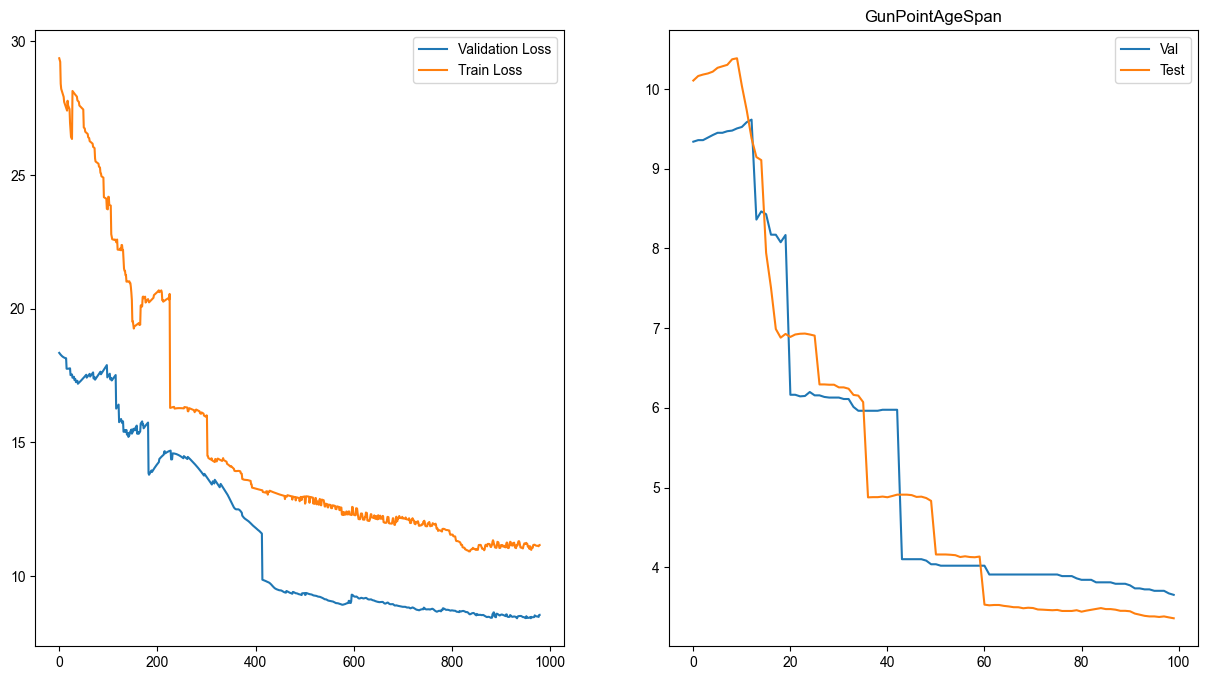

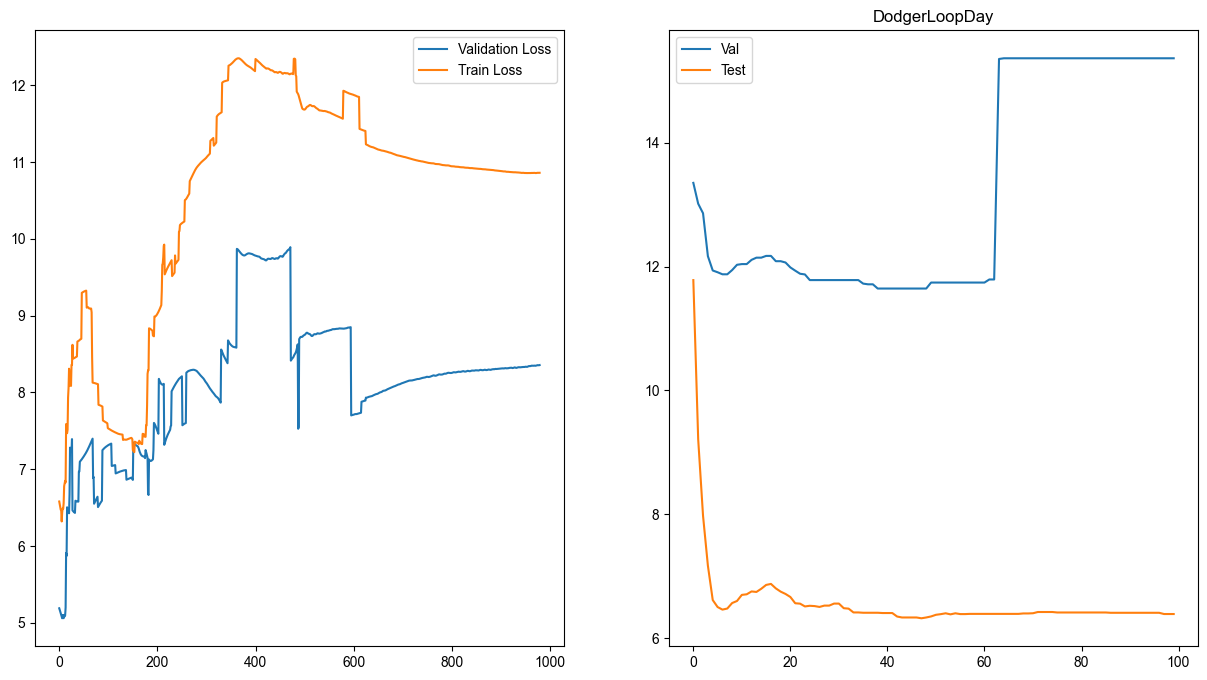

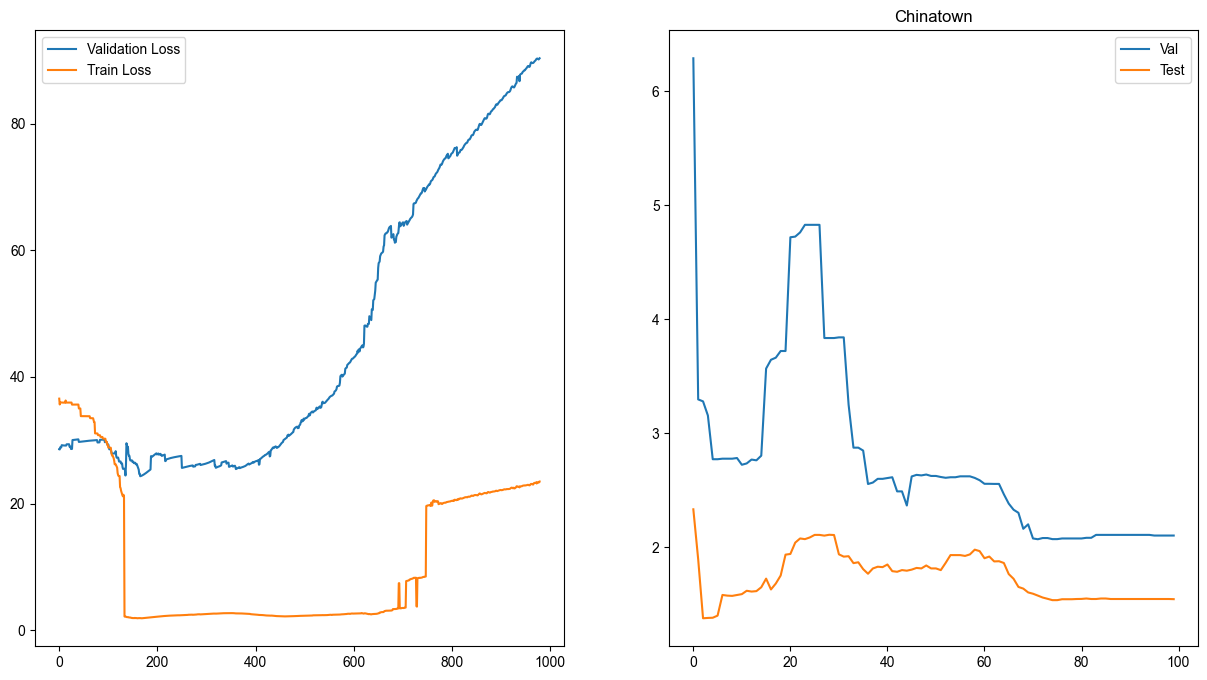

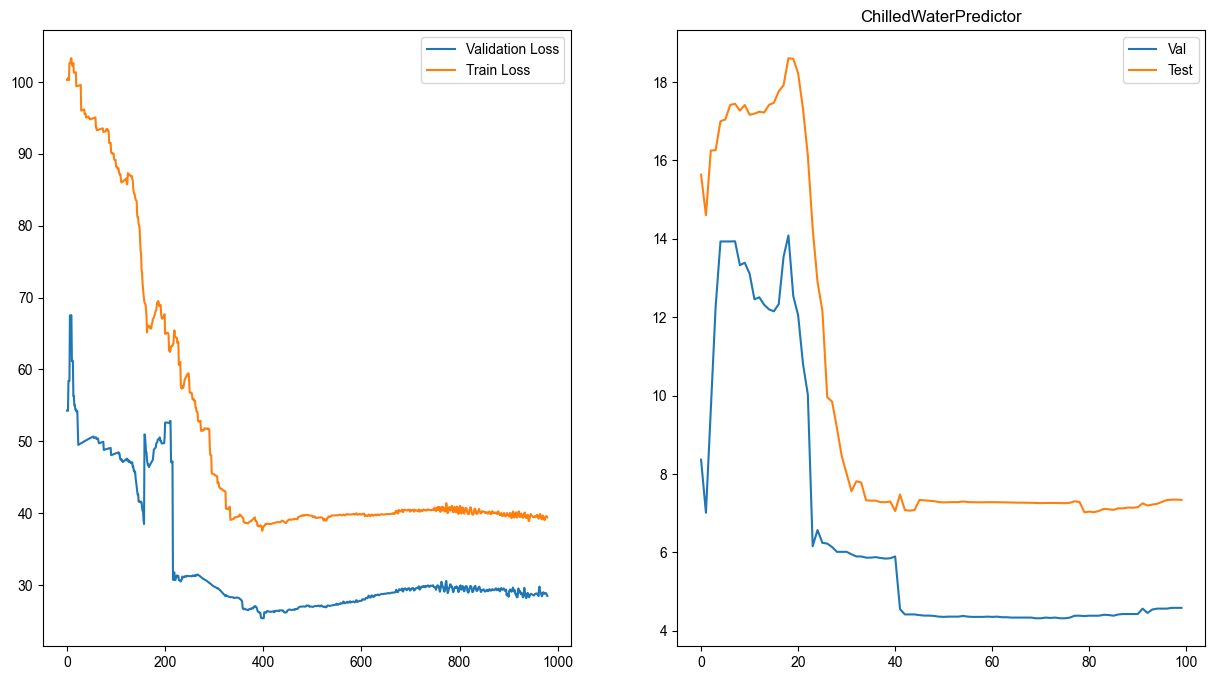

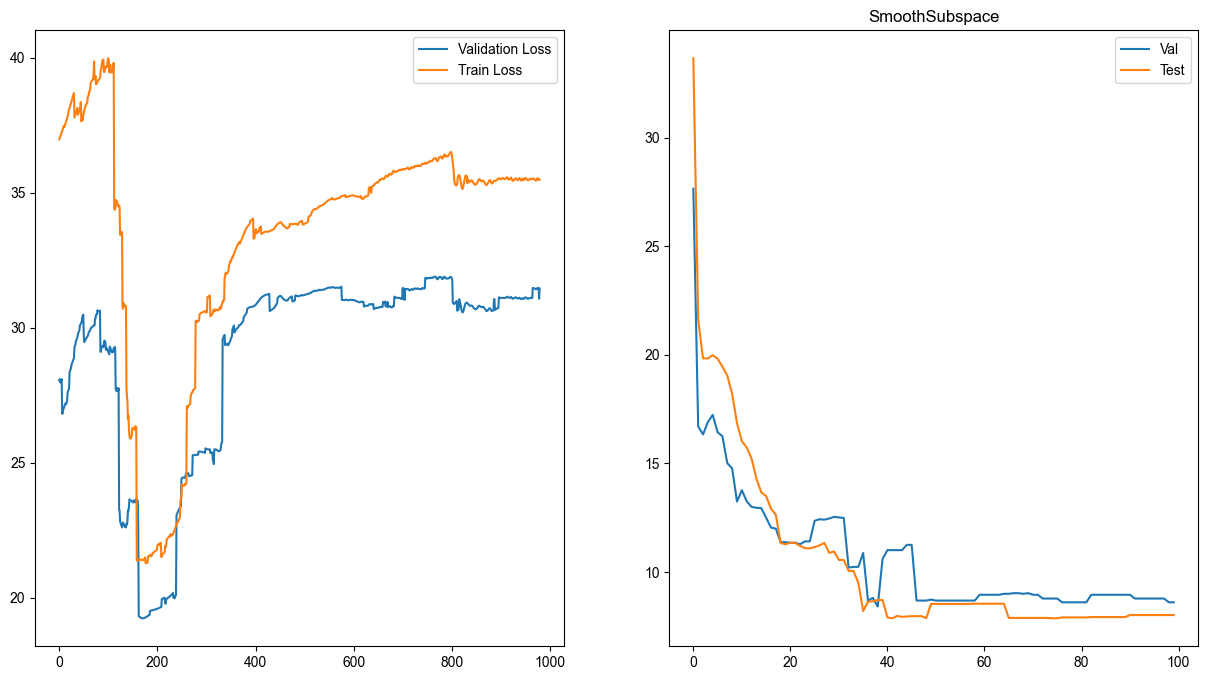

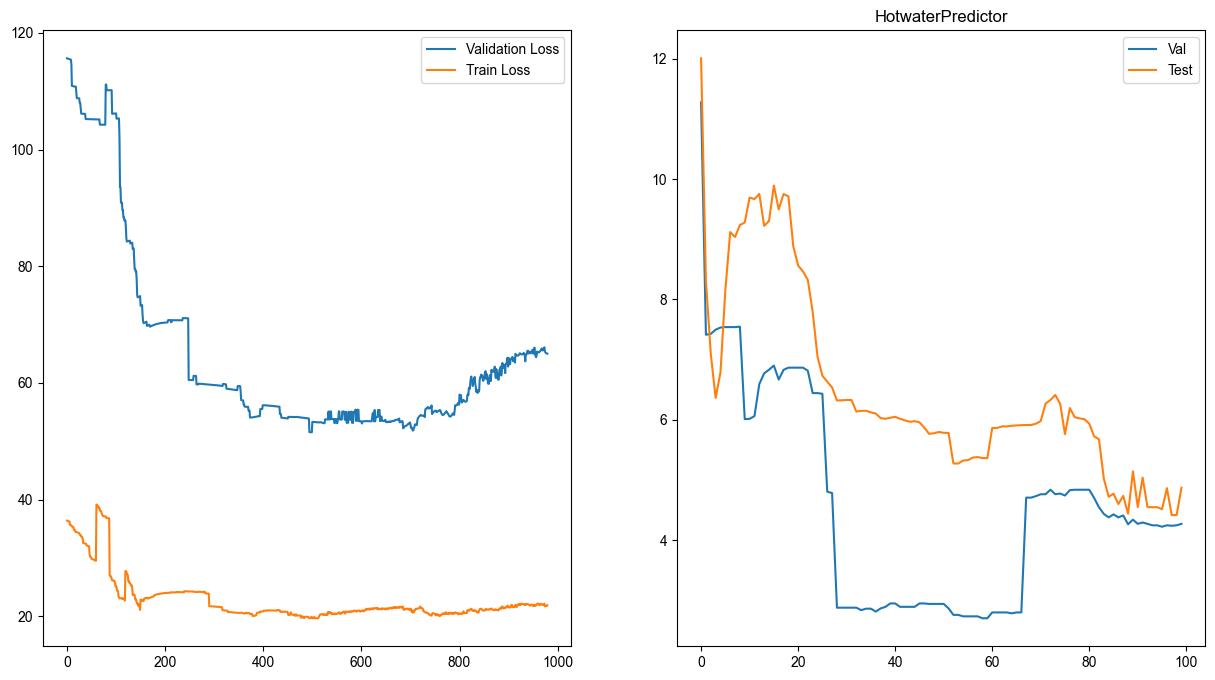

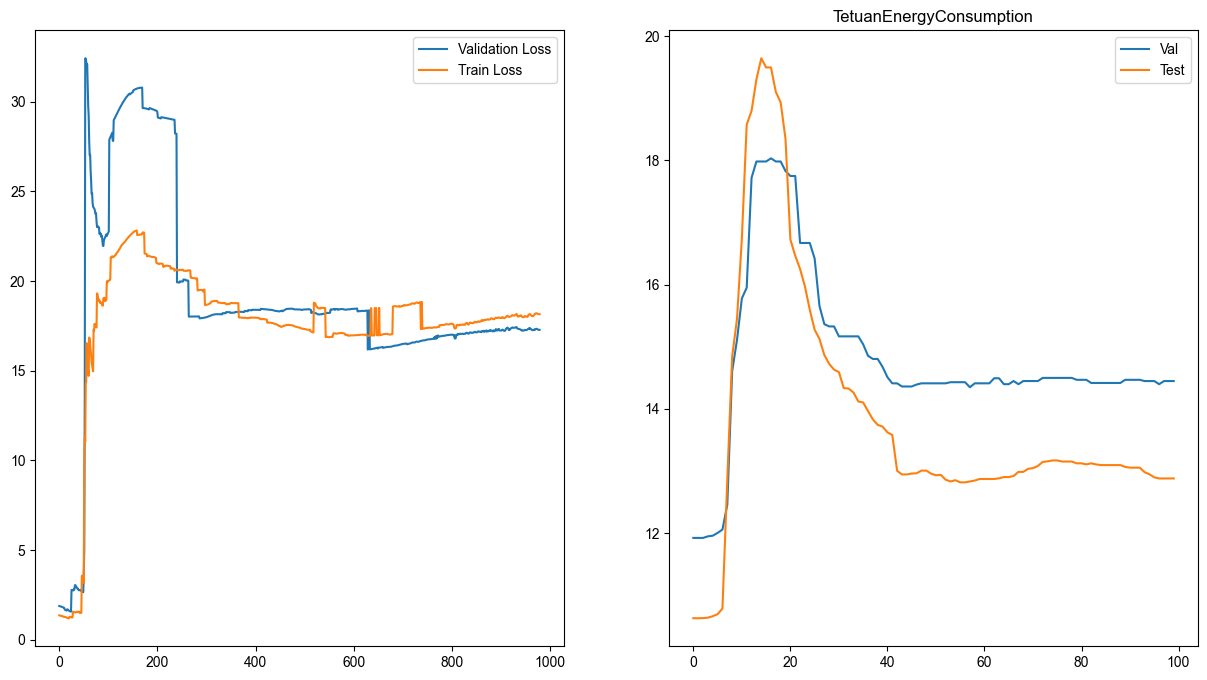

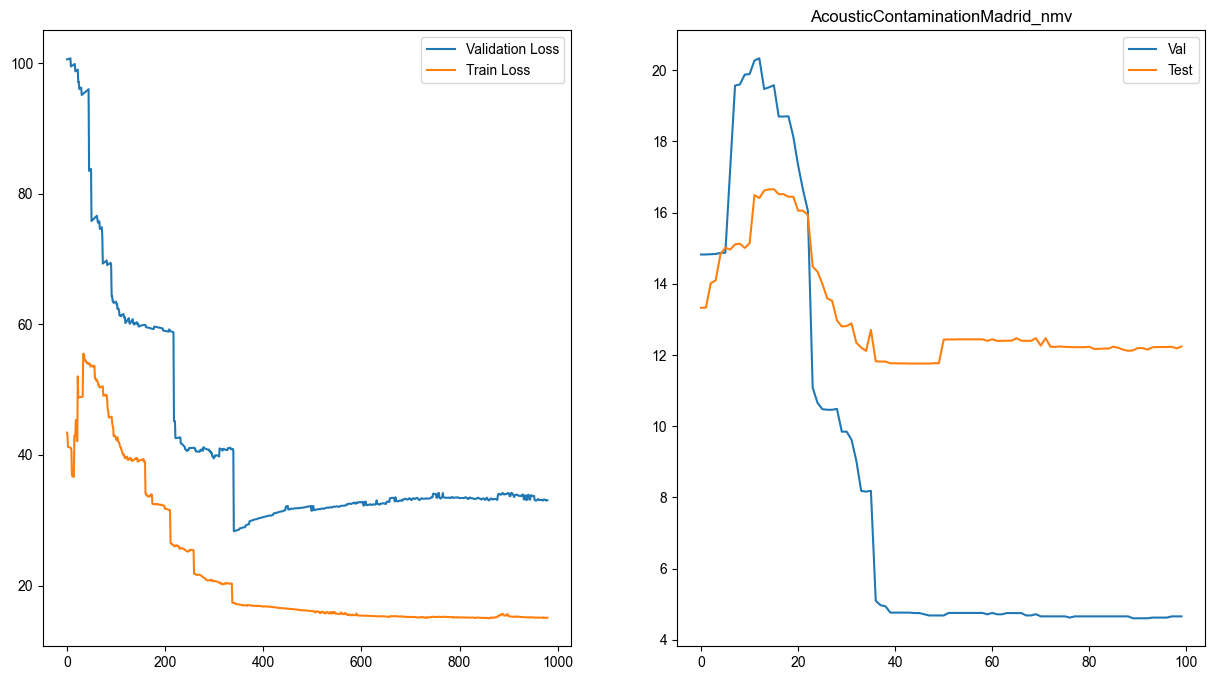

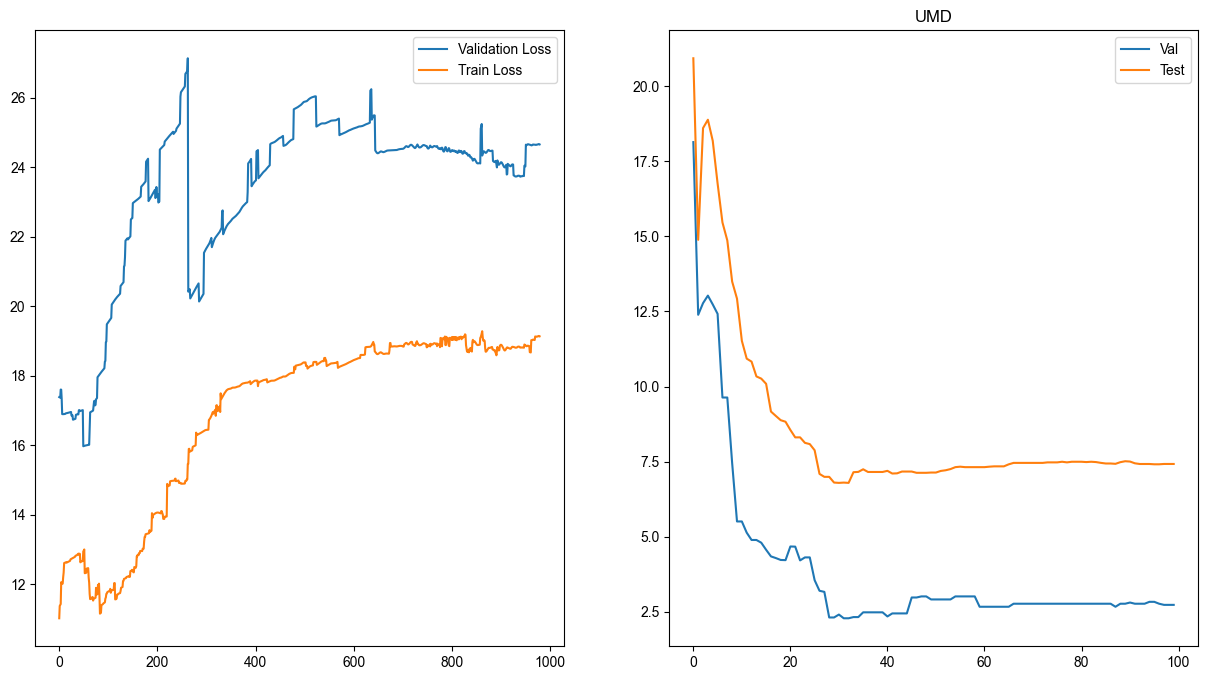

In [41]:
for dataset in datasets :
        fig, axes = plt.subplots(1,2,figsize=(15,8))
        
        
        axes[0].plot(val_losses['CALIMERA_one_reg']['0.5'][dataset], label='Validation Loss')
        axes[0].plot(train_losses['CALIMERA_one_reg']['0.5'][dataset], label='Train Loss')
        axes[0].legend()
       
        axes[1].plot(avg_val['CALIMERA_one_reg']['0.5'][dataset],label='Val')
        axes[1].plot(avg_test['CALIMERA_one_reg']['0.5'][dataset],label='Test')
        
        axes[1].legend()
        
        plt.title(f'{dataset}')

### at training time, no mask

In [53]:
json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\metrics_all_non_z_norm_unb_exp_delay.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    metrics = json.load(file)



json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\metrics_target_flatten_one_reg_val_model_selection_unb_exp_delay_collection_8.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    metrics_one_reg = json.load(file)

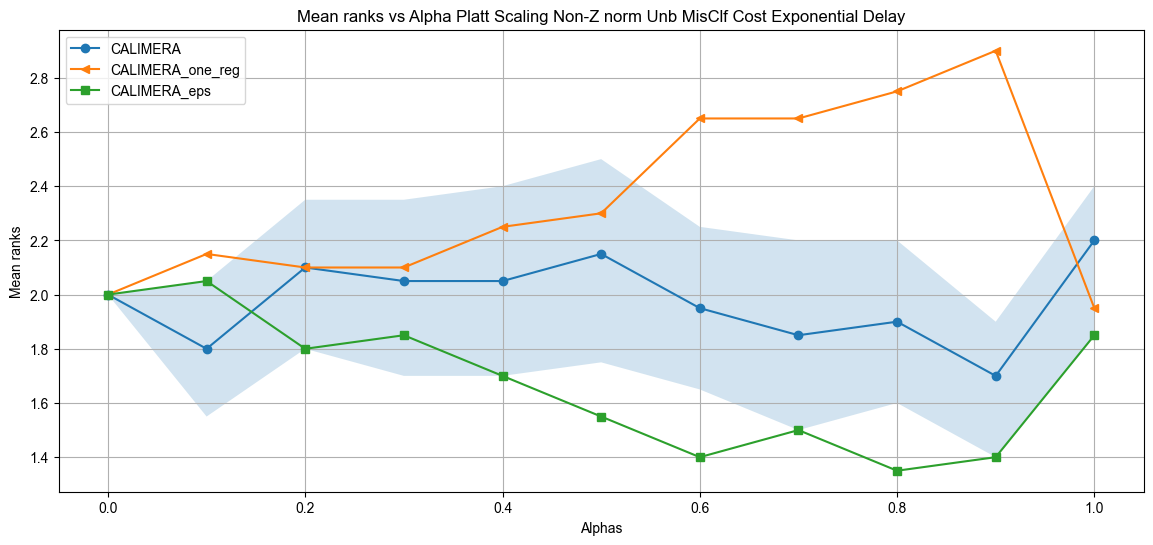

In [54]:
pivot_df=plot_ranks(metrics_one_reg,metrics)

In [55]:
pivot_df[pivot_df['Alpha']=='0.1']

Trigger,Alpha,Dataset,CALIMERA,CALIMERA_eps,CALIMERA_one_reg
10,0.1,AcousticContaminationMadrid_nmv,3.345336,3.345336,3.212798
11,0.1,BME,1.426843,1.426843,2.978208
12,0.1,ChilledWaterPredictor,2.703285,2.712718,2.722127
13,0.1,Chinatown,1.197902,1.197902,1.197902
14,0.1,DodgerLoopDay,2.234142,2.520773,2.234142
15,0.1,GunPointAgeSpan,1.997114,1.997114,2.823090
16,0.1,HotwaterPredictor,2.071766,2.071766,2.256526
17,0.1,SmoothSubspace,2.923421,2.923421,2.923421
18,0.1,TetuanEnergyConsumption,3.125809,3.125809,3.125809
19,0.1,UMD,3.168381,3.168381,2.983955


In [56]:
json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\metrics_all_non_z_norm_unb_exp_delay.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    metrics = json.load(file)



json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\metrics_target_flatten_one_reg_val_model_selection_unb_exp_delay_collection_9.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    metrics_one_reg = json.load(file)

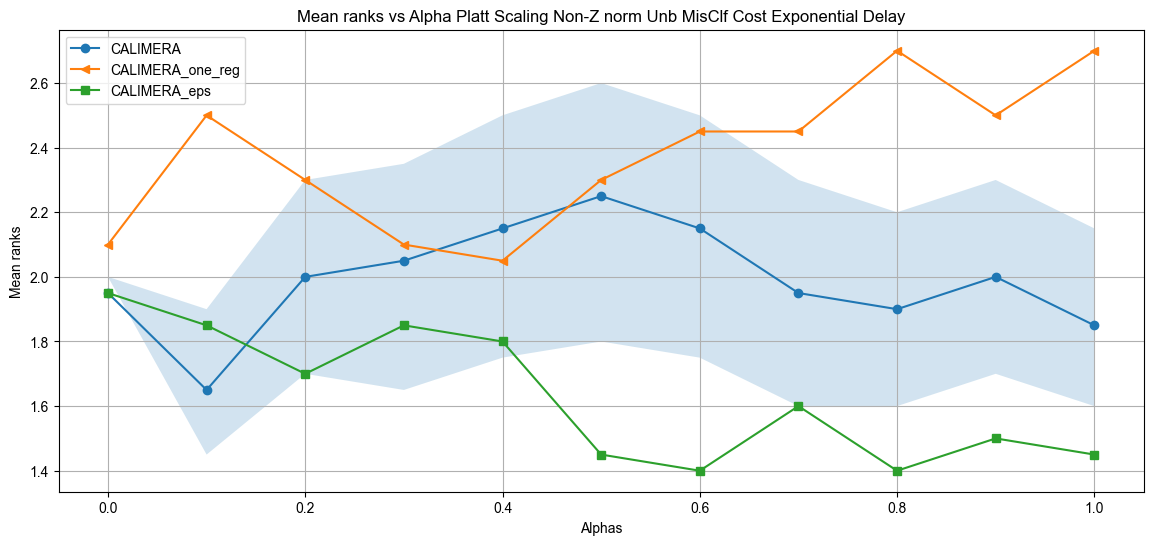

In [57]:
pivot_df=plot_ranks(metrics_one_reg,metrics)

In [58]:
pivot_df[pivot_df['Alpha']=='0.1']

Trigger,Alpha,Dataset,CALIMERA,CALIMERA_eps,CALIMERA_one_reg
10,0.1,AcousticContaminationMadrid_nmv,3.345336,3.345336,3.212798
11,0.1,BME,1.426843,1.426843,1.919124
12,0.1,ChilledWaterPredictor,2.703285,2.712718,2.722127
13,0.1,Chinatown,1.197902,1.197902,1.197902
14,0.1,DodgerLoopDay,2.234142,2.520773,2.545855
15,0.1,GunPointAgeSpan,1.997114,1.997114,2.437983
16,0.1,HotwaterPredictor,2.071766,2.071766,2.138226
17,0.1,SmoothSubspace,2.923421,2.923421,2.923421
18,0.1,TetuanEnergyConsumption,3.125809,3.125809,3.125809
19,0.1,UMD,3.168381,3.168381,3.520625


### no flatten , early stop, full, grad clip

In [62]:
json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\metrics_all_non_z_norm_unb_exp_delay.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    metrics = json.load(file)



json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\metrics_target_flatten_one_reg_val_model_selection_unb_exp_delay_collection_10.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    metrics_one_reg = json.load(file)

In [ ]:
metrics_one_reg['CALIMERA_one_reg']['0.0']['']

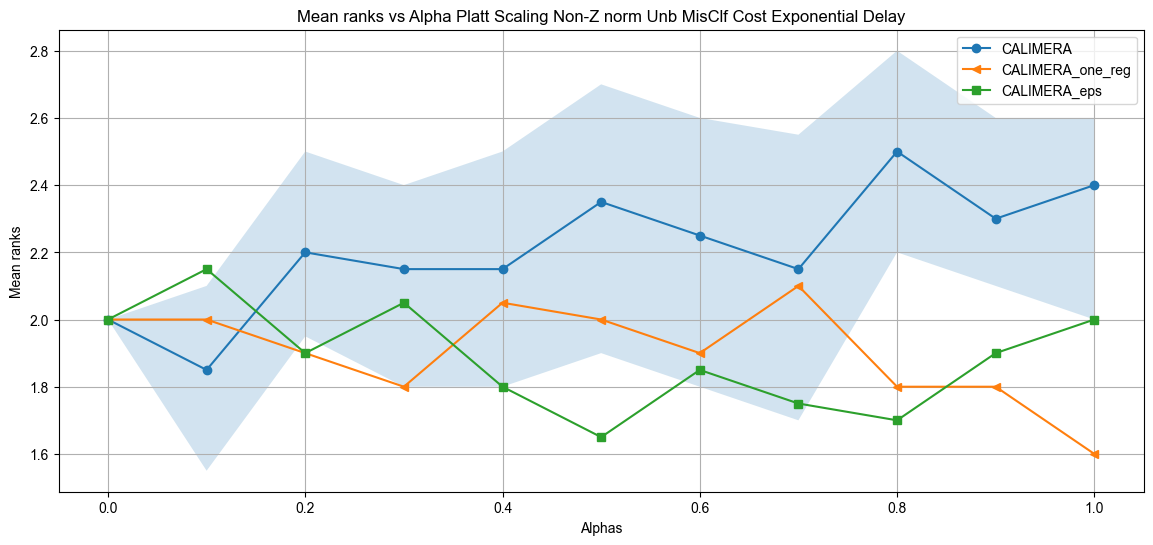

In [60]:
pivot_df=plot_ranks(metrics_one_reg,metrics)

In [61]:
pivot_df[pivot_df['Alpha']=='1.0']

Trigger,Alpha,Dataset,CALIMERA,CALIMERA_eps,CALIMERA_one_reg
100,1.0,AcousticContaminationMadrid_nmv,19.444444,19.444444,18.069444
101,1.0,BME,0.204545,0.363636,0.363636
102,1.0,ChilledWaterPredictor,16.724638,12.427536,13.869565
103,1.0,Chinatown,1.075269,1.075269,0.010753
104,1.0,DodgerLoopDay,11.125000,11.125000,11.062500
105,1.0,GunPointAgeSpan,6.097561,4.878049,6.097561
106,1.0,HotwaterPredictor,8.537736,7.603774,4.801887
107,1.0,SmoothSubspace,2.805556,2.805556,2.777778
108,1.0,TetuanEnergyConsumption,17.318182,16.445455,19.136364
109,1.0,UMD,6.886364,6.886364,2.295455


In [73]:
def plot_wilcoxon_test(metric,pivot_df,alpha):
    
    

    pivot_df_alpha_0_5 = pivot_df[pivot_df['Alpha'] == alpha].copy()
    pivot_df_alpha_0_5.drop(columns=['Alpha'], inplace=True)
    # remove index 
    pivot_df_alpha_0_5.reset_index(drop=True, inplace=True)
    competitors = [col for col in pivot_df_alpha_0_5.columns if col != 'Dataset']


    # Transform the pivot_df to have columns: competitor, dataset, and metric
   
    
    transformed_df = pivot_df_alpha_0_5.melt(id_vars=['Dataset'], 
                               value_vars=competitors, 
                               var_name='competitor', 
                               value_name='metric')
 

    # rename Dataset to dataset
    transformed_df.rename(columns={'Dataset': 'dataset'}, inplace=True)
    # Draw the critical difference diagram
    if metric=='average_cost' or metric=='earliness':
        draw_cd_diagram(df=transformed_df, title=f'{alpha} Wilcoxon signed-rank test labeled with mean {metric}',pairwise_matrix='uncorrected', labels='metric',ascending='True')   
    else:
        draw_cd_diagram(df=transformed_df, title=f'{alpha} Wilcoxon signed-rank test labeled with mean {metric}',pairwise_matrix='uncorrected', labels='metric',ascending='False')

In [69]:
json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\metrics_all_non_z_norm_unb_exp_delay.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    metrics = json.load(file)



json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\metrics_target_flatten_one_reg_val_model_selection_unb_exp_delay_collection_11.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    metrics_one_reg = json.load(file)

In [70]:
def plot_ranks(metrics_one_reg,metrics):
    datasets = ["BME","Chinatown","Crop","DodgerLoopDay","EOGVerticalSignal","GestureMidAirD1","GunPointAgeSpan","HouseTwenty","MelbournePedestrian","PLAID","Rock","SemgHandGenderCh2","SmoothSubspace","UMD",
                "AcousticContaminationMadrid_nmv", "AluminiumConcentration", "BitcoinSentiment", "ChilledWaterPredictor",
                "DhakaHourlyAirQuality", "ElectricityPredictor", "FloodModeling3","HouseholdPowerConsumption1",
                "HotwaterPredictor", "MadridPM10Quality_nmv", "ParkingBirmingham_eq", "PrecipitationAndalusia_nmv", "SolarRadiationAndalusia_nmv",
                "SteamPredictor", "TetuanEnergyConsumption", "WindTurbinePower"]
    
    alphas = ['0.0' , '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '1.0']
    
   
    

    metrics_one_reg['CALIMERA']={alpha: {dataset: None for dataset in datasets} for alpha in alphas}
    metrics_one_reg['CALIMERA_eps']={alpha: {dataset: None for dataset in datasets} for alpha in alphas}

    for alpha in alphas :
        for dataset in datasets :
            metrics_one_reg['CALIMERA'][alpha][dataset]=metrics['CALIMERA'][alpha][dataset]
            metrics_one_reg['CALIMERA_eps'][alpha][dataset]=metrics['CALIMERA_eps'][alpha][dataset]

    data = []
    for trigger, alphas in metrics_one_reg.items():
        for alpha, datasets in alphas.items():
            for dataset, values in datasets.items():
                data.append({
                'Trigger': trigger,
                'Alpha': alpha,
                'Dataset': dataset,
                'Average Cost': values['average_cost']
                
            })

# Create a DataFrame
    df = pd.DataFrame(data)

# Pivot the DataFrame to get triggers as columns
    pivot_df = df.pivot_table(index=['Alpha', 'Dataset'], columns='Trigger', values='Average Cost')

# Reset index to flatten the DataFrame
    pivot_df.reset_index(inplace=True)




# for each row rank the triggers
    ranked_df = pivot_df.copy()
    ranked_df.iloc[:, 2:] = ranked_df.iloc[:, 2:].rank(axis=1, method='average', ascending=True)

    ranked_df.columns = ['Alpha', 'Dataset'] + [f'Rank {col}' for col in ranked_df.columns[2:]]

    ranks_calimera = ranked_df.groupby('Alpha')['Rank CALIMERA']
    ranks_calimera_eps = ranked_df.groupby('Alpha')['Rank CALIMERA_eps']

    ranks_calimera_one_reg = ranked_df.groupby('Alpha')['Rank CALIMERA_one_reg']

    ranks_calimera_mean = ranks_calimera.mean()
    ranks_calimera_eps_mean = ranks_calimera_eps.mean()



    ranks_calimera_one_reg_mean = ranks_calimera_one_reg.mean()




    ranks_calimera_array = ranks_calimera.apply(list).to_numpy()


    ci_lower_cal, ci_upper_cal = get_confidence_interval(ranks_calimera_array)


    alphas = np.array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])
# plot the mean w.r.t alphas for each trigger
    plt.figure(figsize=(14, 6))
    plt.plot(alphas, ranks_calimera_mean, label='CALIMERA', marker='o')
    plt.fill_between(alphas, ci_lower_cal,ci_upper_cal, alpha=.2)

    plt.plot(alphas, ranks_calimera_one_reg_mean, label='CALIMERA_one_reg', marker='<')
    plt.plot(alphas, ranks_calimera_eps_mean, label='CALIMERA_true_target', marker='s')
    plt.xlabel('Alphas')
    plt.ylabel('Mean ranks')
    plt.title('Mean ranks vs Alpha Platt Scaling Non-Z norm Unb MisClf Cost Exponential Delay')
    plt.legend()
    plt.grid()
    plt.show()
    return pivot_df

### batch size *5

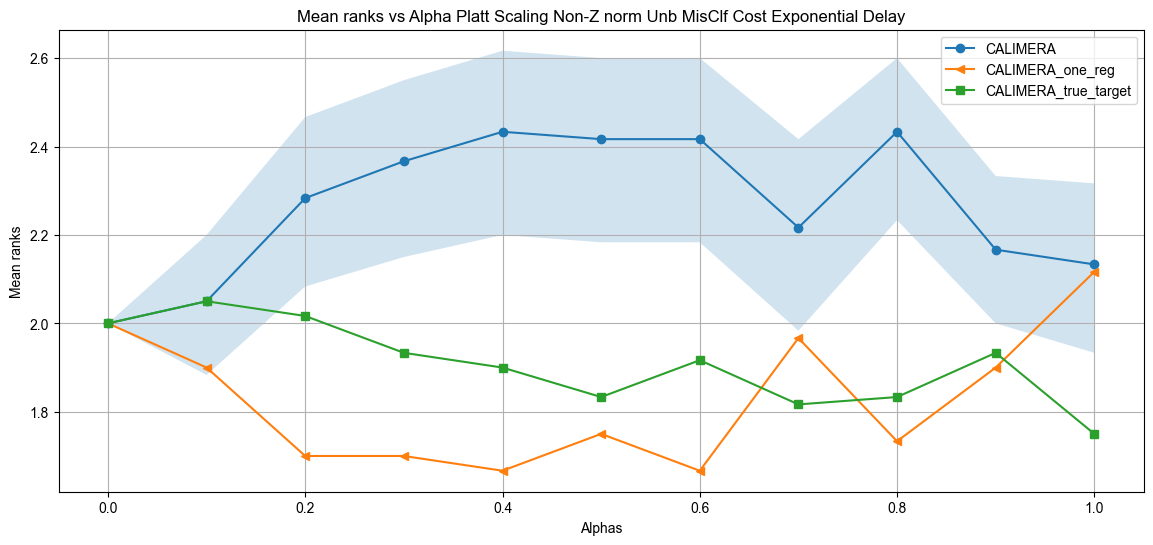

In [71]:
pivot_df = plot_ranks(metrics_one_reg,metrics)

In [111]:
pivot_df[pivot_df['Alpha']=='0.5']

Trigger,Alpha,Dataset,CALIMERA,CALIMERA_one_reg,CALIMERA_true_target
150,0.5,AcousticContaminationMadrid_nmv,10.710458,11.236631,11.710337
151,0.5,AluminiumConcentration,9.937903,8.348684,11.392610
152,0.5,BME,1.148578,1.192380,1.183660
153,0.5,BitcoinSentiment,11.212679,10.213776,11.647101
154,0.5,ChilledWaterPredictor,8.081316,7.691412,12.143234
155,0.5,Chinatown,1.227471,1.143398,1.670690
156,0.5,Crop,2.845994,1.775576,3.270305
157,0.5,DhakaHourlyAirQuality,3.281017,1.851236,3.906271
158,0.5,DodgerLoopDay,6.344874,6.507311,6.344874
159,0.5,EOGVerticalSignal,3.651958,4.047572,3.687104


### batch size 10 *

In [74]:

json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\metrics_all_non_z_norm_unb_exp_delay.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    metrics = json.load(file)



json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\metrics_target_flatten_one_reg_val_model_selection_unb_exp_delay_collection_12.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    metrics_one_reg = json.load(file)

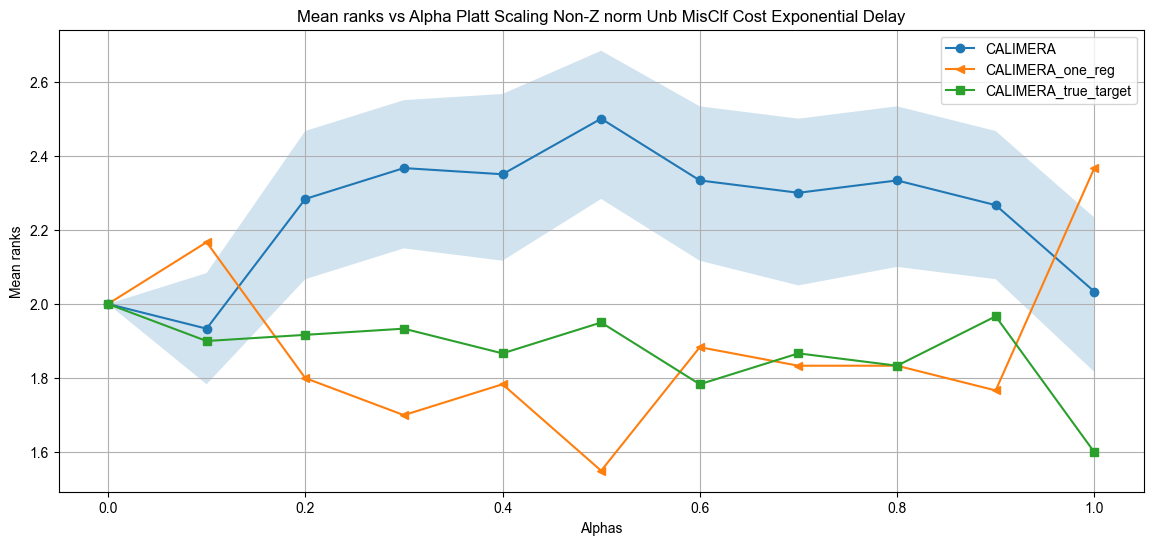

In [75]:
pivot_df = plot_ranks(metrics_one_reg,metrics)

In [79]:
def plot_ranks_eps(metrics_one_reg,metrics):
    datasets = ["BME","Chinatown","Crop","DodgerLoopDay","EOGVerticalSignal","GestureMidAirD1","GunPointAgeSpan","HouseTwenty","MelbournePedestrian","PLAID","Rock","SemgHandGenderCh2","SmoothSubspace","UMD",
                "AcousticContaminationMadrid_nmv", "AluminiumConcentration", "BitcoinSentiment", "ChilledWaterPredictor",
                "DhakaHourlyAirQuality", "ElectricityPredictor", "FloodModeling3","HouseholdPowerConsumption1",
                "HotwaterPredictor", "MadridPM10Quality_nmv", "ParkingBirmingham_eq", "PrecipitationAndalusia_nmv", "SolarRadiationAndalusia_nmv",
                "SteamPredictor", "TetuanEnergyConsumption", "WindTurbinePower"]
    
    alphas = ['0.0' , '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '1.0']
    
   
    

    metrics_one_reg['CALIMERA']={alpha: {dataset: None for dataset in datasets} for alpha in alphas}
    metrics_one_reg['CALIMERA_eps']={alpha: {dataset: None for dataset in datasets} for alpha in alphas}

    for alpha in alphas :
        for dataset in datasets :
            metrics_one_reg['CALIMERA'][alpha][dataset]=metrics['CALIMERA'][alpha][dataset]
            metrics_one_reg['CALIMERA_eps'][alpha][dataset]=metrics['CALIMERA_eps'][alpha][dataset]

    data = []
    for trigger, alphas in metrics_one_reg.items():
        for alpha, datasets in alphas.items():
            for dataset, values in datasets.items():
                data.append({
                'Trigger': trigger,
                'Alpha': alpha,
                'Dataset': dataset,
                'Average Cost': values['average_cost']
                
            })

# Create a DataFrame
    df = pd.DataFrame(data)

# Pivot the DataFrame to get triggers as columns
    pivot_df = df.pivot_table(index=['Alpha', 'Dataset'], columns='Trigger', values='Average Cost')

# Reset index to flatten the DataFrame
    pivot_df.reset_index(inplace=True)




# for each row rank the triggers
    ranked_df = pivot_df.copy()
    ranked_df.iloc[:, 2:] = ranked_df.iloc[:, 2:].rank(axis=1, method='average', ascending=True)

    ranked_df.columns = ['Alpha', 'Dataset'] + [f'Rank {col}' for col in ranked_df.columns[2:]]

    ranks_calimera = ranked_df.groupby('Alpha')['Rank CALIMERA']
    ranks_calimera_eps = ranked_df.groupby('Alpha')['Rank CALIMERA_eps']

    ranks_calimera_one_reg = ranked_df.groupby('Alpha')['Rank CALIMERA_one_reg']

    ranks_calimera_mean = ranks_calimera.mean()
    ranks_calimera_eps_mean = ranks_calimera_eps.mean()



    ranks_calimera_one_reg_mean = ranks_calimera_one_reg.mean()




    ranks_calimera_array = ranks_calimera.apply(list).to_numpy()
    ci_lower_cal, ci_upper_cal = get_confidence_interval(ranks_calimera_array)

    ranks_calimera_eps_array = ranks_calimera_eps.apply(list).to_numpy()
    ci_lower_cal_eps, ci_upper_cal_eps = get_confidence_interval(ranks_calimera_eps_array)

    ranks_calimera_one_reg_array = ranks_calimera_one_reg.apply(list).to_numpy()
    ci_lower_cal_one_reg, ci_upper_cal_one_reg = get_confidence_interval(ranks_calimera_one_reg_array)


    alphas = np.array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])
# plot the mean w.r.t alphas for each trigger
    plt.figure(figsize=(14, 6))
    plt.plot(alphas, ranks_calimera_mean, label='CALIMERA', marker='o')
    #plt.fill_between(alphas, ci_lower_cal,ci_upper_cal, alpha=.2)

    
    plt.plot(alphas, ranks_calimera_eps_mean, label='CALIMERA_eps', marker='s')
    #plt.fill_between(alphas, ci_lower_cal_eps,ci_upper_cal_eps, alpha=.2)
    plt.plot(alphas, ranks_calimera_one_reg_mean, label='CALIMERA-One-Reg', marker='<')
    #plt.fill_between(alphas, ci_lower_cal_one_reg,ci_upper_cal_one_reg, alpha=.2)
    plt.xlabel('Alphas')
    plt.ylabel('Mean ranks')
   
    plt.legend()
    plt.grid()
    plt.show()
    return pivot_df

In [51]:

json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\metrics_all_non_z_norm_unb_exp_delay.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    metrics = json.load(file)


json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\metrics_target_flatten_one_reg_val_model_selection_unb_exp_delay_collection_12.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    metrics_one_reg = json.load(file)

In [52]:
datasets = ["BME","Chinatown","Crop","DodgerLoopDay","EOGVerticalSignal","GestureMidAirD1","GunPointAgeSpan","HouseTwenty","MelbournePedestrian","PLAID","Rock","SemgHandGenderCh2","SmoothSubspace","UMD",
                "AcousticContaminationMadrid_nmv", "AluminiumConcentration", "BitcoinSentiment", "ChilledWaterPredictor",
                "DhakaHourlyAirQuality", "ElectricityPredictor", "FloodModeling3","HouseholdPowerConsumption1",
                "HotwaterPredictor", "MadridPM10Quality_nmv", "ParkingBirmingham_eq", "PrecipitationAndalusia_nmv", "SolarRadiationAndalusia_nmv",
                "SteamPredictor", "TetuanEnergyConsumption", "WindTurbinePower"]
for dataset in datasets :   
    print(metrics_one_reg['CALIMERA_one_reg']['0.9'][dataset]['earliness'],end='\t')
    print(metrics['CALIMERA']['0.9'][dataset]['earliness'])

0.13529829545454544	0.19211647727272727
0.16845878136200718	0.2948028673835125
0.1282548309178744	0.41713164251207724
0.0744357638888889	0.09722222222222222
0.3961137614678899	0.41612110091743115
0.07450980392156863	0.3563725490196078
0.19317073170731708	0.3896747967479675
0.115625	0.1
0.13960244648318043	0.3682339449541285
0.1320588810754198	0.19767283943512837
0.5260531779519121	0.33088875493938785
0.12846153846153846	0.5635897435897436
0.23333333333333334	0.6518518518518519
0.2922727272727273	0.43803030303030305
0.24235159817351598	0.14794520547945206
0.10971030601243031	0.5747026671495593
0.1575	0.33499999999999996
0.08846618357487923	0.2766131815044859
0.1044015029522276	0.3170289855072464
0.21996864589457182	0.44745737801293356
0.049403399803857474	0.786388525661981
0.15616279069767441	0.5927906976744186
0.12219227313566935	0.4360961365678347
0.1394840314556251	0.4715477909989224
0.37903804737975594	0.5629337162000478
0.12425064424250645	0.350183100501831
0.19184863691848636	0.40

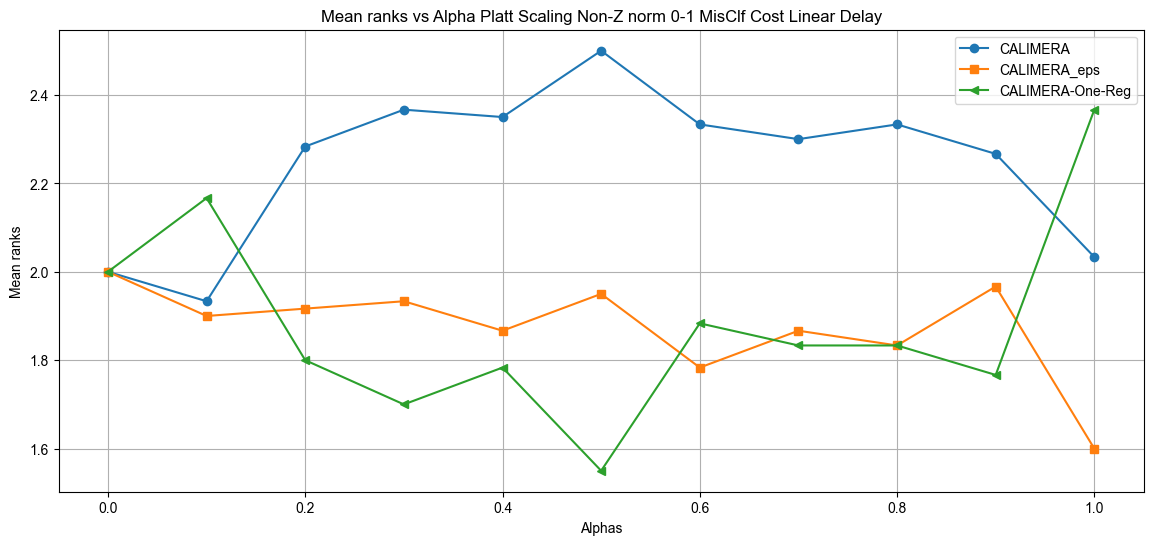

In [26]:
pivot_df = plot_ranks_eps(metrics_one_reg,metrics)

In [28]:
pivot_df[pivot_df['Alpha']=='0.5']

Trigger,Alpha,Dataset,CALIMERA,CALIMERA_eps,CALIMERA_one_reg
150,0.5,AcousticContaminationMadrid_nmv,10.710458,10.563322,10.667025
151,0.5,AluminiumConcentration,9.937903,8.950776,7.991227
152,0.5,BME,1.148578,0.974509,2.236851
153,0.5,BitcoinSentiment,11.212679,10.718952,9.730730
154,0.5,ChilledWaterPredictor,8.081316,7.324061,6.815505
155,0.5,Chinatown,1.227471,1.146154,0.609897
156,0.5,Crop,2.845994,2.528122,1.691814
157,0.5,DhakaHourlyAirQuality,3.281017,2.535023,1.917997
158,0.5,DodgerLoopDay,6.344874,6.344874,6.310564
159,0.5,EOGVerticalSignal,3.651958,3.006591,4.073705


['CALIMERA' 'CALIMERA_eps' 'CALIMERA_one_reg']
CALIMERA             3.0
CALIMERA_eps         6.0
CALIMERA_one_reg    18.0
dtype: float64
CALIMERA            2.50
CALIMERA_eps        1.95
CALIMERA_one_reg    1.55
dtype: float64
('CALIMERA', 'CALIMERA_eps', 0.0175064677296368, False)
('CALIMERA', 'CALIMERA_one_reg', 0.030797788876709423, False)
('CALIMERA_eps', 'CALIMERA_one_reg', 0.0406491397374963, False)


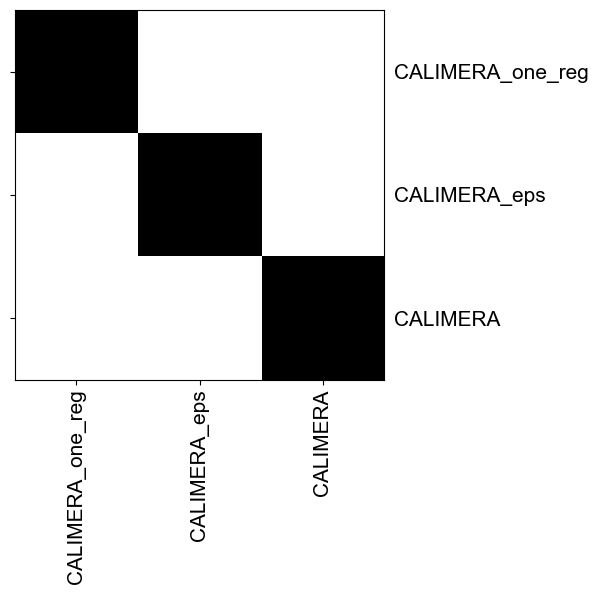

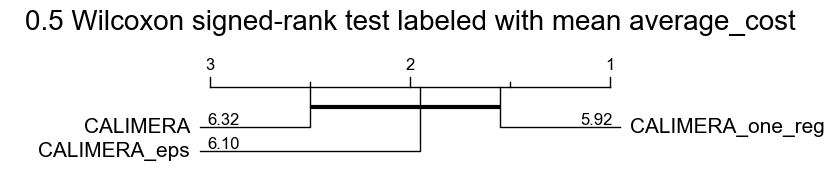

In [246]:
plot_wilcoxon_test('average_cost',pivot_df,'0.5')

In [29]:

json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\avg_val_one_reg_target_flatten_val_model_selection_unb_exp_delay_collection_12.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    avg_val = json.load(file)



json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\avg_test_one_reg_target_flatten_val_model_selection_unb_exp_delay_collection_12.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    avg_test = json.load(file)
json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\val_losses_one_reg_target_flatten_val_model_selection_unb_exp_delay_collection_12.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    val_losses = json.load(file)
json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\train_losses_one_reg_target_flatten_val_model_selection_unb_exp_delay_collection_12.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    train_losses = json.load(file)

json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\best_epoch_one_reg_target_flatten_val_model_selection_unb_exp_delay_collection_12.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    best_epoch = json.load(file)

In [30]:
datasets = ["BME","Chinatown","DodgerLoopDay","EOGVerticalSignal","GestureMidAirD1","GunPointAgeSpan","HouseTwenty","MelbournePedestrian","PLAID","Rock","SemgHandGenderCh2","SmoothSubspace","UMD",
                "AcousticContaminationMadrid_nmv", "AluminiumConcentration", "BitcoinSentiment", "ChilledWaterPredictor",
                "DhakaHourlyAirQuality", "ElectricityPredictor", "FloodModeling3","HouseholdPowerConsumption1",
                "HotwaterPredictor", "MadridPM10Quality_nmv", "ParkingBirmingham_eq", "PrecipitationAndalusia_nmv", "SolarRadiationAndalusia_nmv",
                "SteamPredictor", "TetuanEnergyConsumption", "WindTurbinePower"]

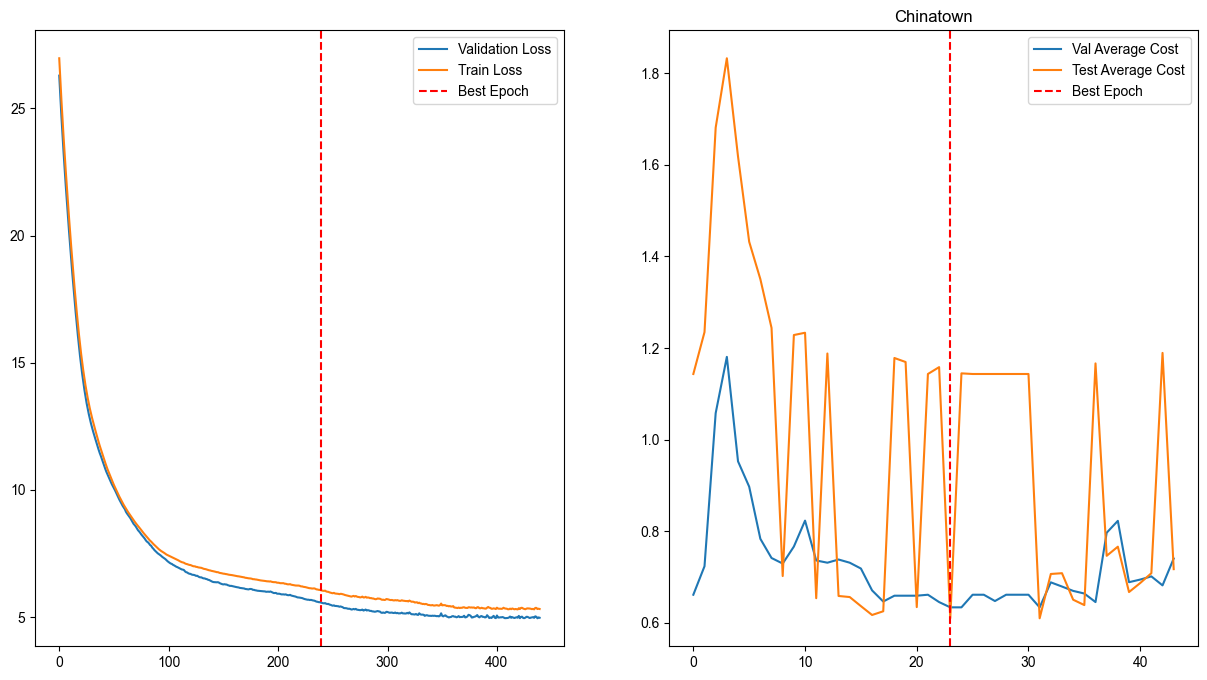

In [38]:
dataset = 'Chinatown'
fig, axes = plt.subplots(1,2,figsize=(15,8))


axes[0].plot(val_losses['CALIMERA_one_reg']['0.5'][dataset], label='Validation Loss')
axes[0].plot(train_losses['CALIMERA_one_reg']['0.5'][dataset], label='Train Loss')
axes[0].axvline(best_epoch['CALIMERA_one_reg']['0.5'][dataset], color='r', linestyle='--', label='Best Epoch')
axes[0].legend()

axes[1].plot(avg_val['CALIMERA_one_reg']['0.5'][dataset],label='Val Average Cost')
axes[1].plot(avg_test['CALIMERA_one_reg']['0.5'][dataset],label='Test Average Cost')
axes[1].axvline((best_epoch['CALIMERA_one_reg']['0.5'][dataset])//10, color='r', linestyle='--', label='Best Epoch')
axes[1].legend()

plt.title(f'{dataset}')
plt.savefig('C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\val_train_test_household.pdf')

In [143]:
pivot_df[pivot_df['Alpha']=='0.0']

Trigger,Alpha,Dataset,CALIMERA,CALIMERA_one_reg,CALIMERA_true_target
0,0.0,AcousticContaminationMadrid_nmv,1.254961,1.254961,1.254961
1,0.0,AluminiumConcentration,1.258697,1.258697,1.258697
2,0.0,BME,1.240938,1.240938,1.240938
3,0.0,BitcoinSentiment,1.211528,1.211528,1.211528
4,0.0,ChilledWaterPredictor,1.245197,1.245197,1.245197
5,0.0,Chinatown,1.211528,1.211528,1.211528
6,0.0,Crop,1.221677,1.221677,1.221677
7,0.0,DhakaHourlyAirQuality,1.211528,1.211528,1.211528
8,0.0,DodgerLoopDay,1.250899,1.250899,1.250899
9,0.0,EOGVerticalSignal,1.256609,1.256609,1.256609


In [152]:

json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\best_epoch_one_reg_target_flatten_val_model_selection_unb_exp_delay_collection_12.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    best_epoch = json.load(file)

In [153]:
best_epoch['CALIMERA_one_reg']['0.0']['PLAID']

49

In [154]:



json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\avg_val_one_reg_target_flatten_val_model_selection_unb_exp_delay_collection_12.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    avg_val_cost = json.load(file)

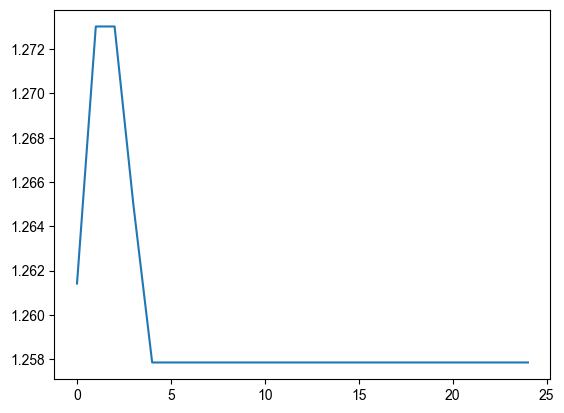

In [155]:
plt.plot(avg_val_cost['CALIMERA_one_reg']['0.0']['PLAID'])

In [156]:
json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\avg_val_one_reg_target_flatten_val_model_selection_unb_exp_delay_collection_13.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    avg_val_cost = json.load(file)

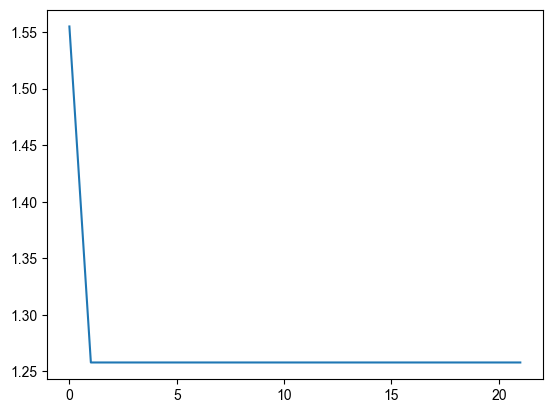

In [157]:
plt.plot(avg_val_cost['CALIMERA_one_reg']['0.0']['PLAID'])

In [142]:
datasets = ["BME","Chinatown","Crop","DodgerLoopDay","EOGVerticalSignal","GestureMidAirD1","GunPointAgeSpan","HouseTwenty","MelbournePedestrian","PLAID","Rock","SemgHandGenderCh2","SmoothSubspace","UMD",
                "AcousticContaminationMadrid_nmv", "AluminiumConcentration", "BitcoinSentiment", "ChilledWaterPredictor",
                "DhakaHourlyAirQuality", "ElectricityPredictor", "FloodModeling3","HouseholdPowerConsumption1",
                "HotwaterPredictor", "MadridPM10Quality_nmv", "ParkingBirmingham_eq", "PrecipitationAndalusia_nmv", "SolarRadiationAndalusia_nmv",
                "SteamPredictor", "TetuanEnergyConsumption", "WindTurbinePower"]
    
L=[]  
for dataset in datasets :
    L.append(metrics_one_reg['CALIMERA_one_reg']['0.9'][dataset]['earliness'])
print(max(L))


0.5260531779519121


['CALIMERA' 'CALIMERA_one_reg' 'CALIMERA_true_target']
CALIMERA                 6.0
CALIMERA_one_reg        22.0
CALIMERA_true_target     0.0
dtype: float64
CALIMERA_true_target    2.766667
CALIMERA                1.800000
CALIMERA_one_reg        1.433333
dtype: float64
('CALIMERA', 'CALIMERA_true_target', 2.3476502077785057e-06, True)
('CALIMERA_one_reg', 'CALIMERA_true_target', 0.0005927448088530608, True)
('CALIMERA', 'CALIMERA_one_reg', 0.030797788876709423, True)


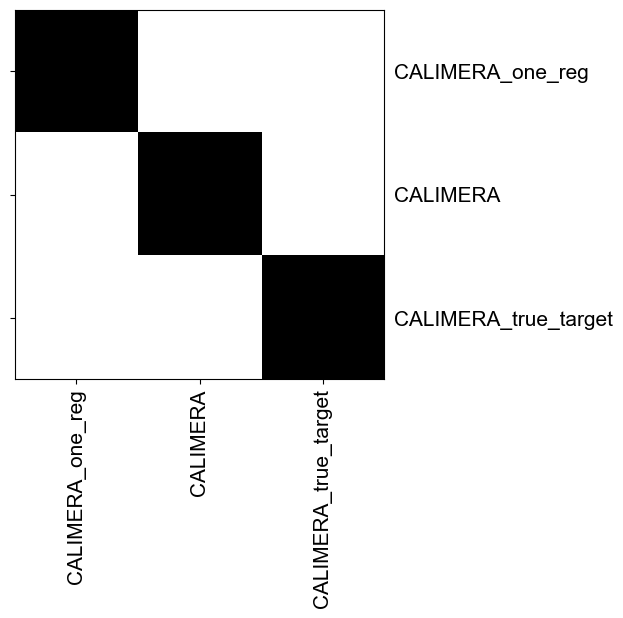

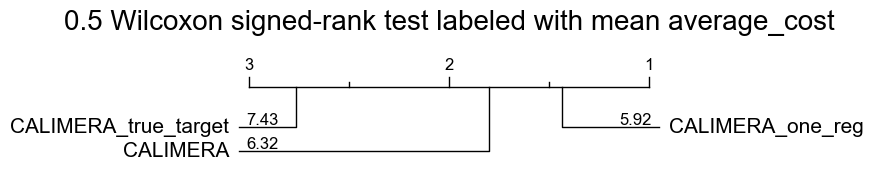

In [133]:
plot_wilcoxon_test('average_cost',pivot_df,'0.5')

### Using flattened

In [80]:
json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\metrics_all_non_z_norm_unb_exp_delay.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    metrics = json.load(file)



json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\metrics_target_flatten_one_reg_val_model_selection_unb_exp_delay_collection_13.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    metrics_one_reg = json.load(file)

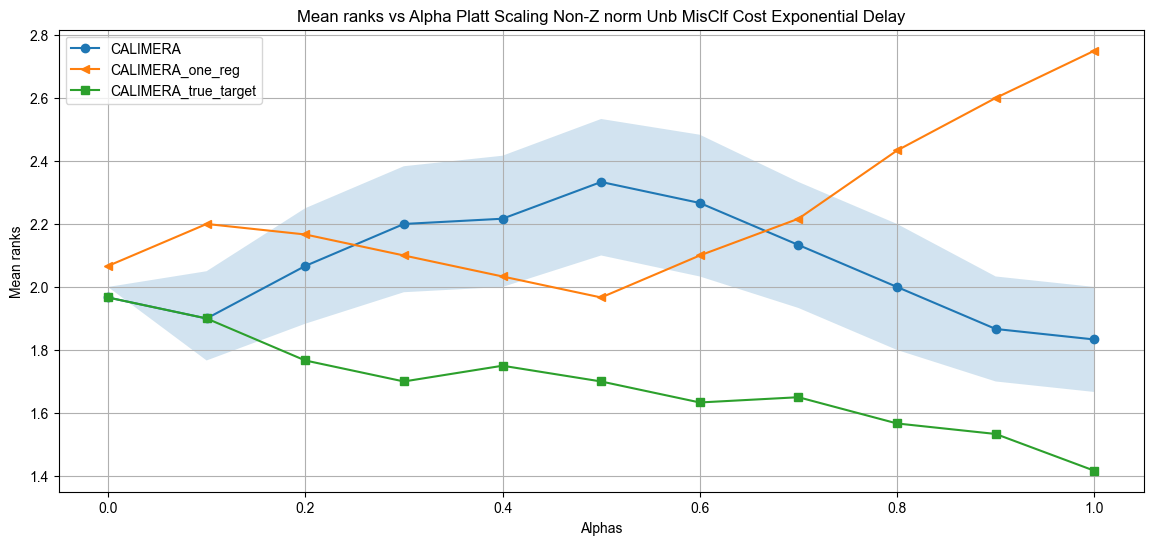

In [81]:
pivot_df = plot_ranks(metrics_one_reg,metrics)

In [82]:
pivot_df[pivot_df['Alpha']=='0.0']

Trigger,Alpha,Dataset,CALIMERA,CALIMERA_eps,CALIMERA_one_reg
0,0.0,AcousticContaminationMadrid_nmv,1.254961,1.254961,1.254961
1,0.0,AluminiumConcentration,1.258697,1.258697,1.258697
2,0.0,BME,1.240938,1.240938,1.240938
3,0.0,BitcoinSentiment,1.211528,1.211528,1.211528
4,0.0,ChilledWaterPredictor,1.245197,1.245197,1.245197
5,0.0,Chinatown,1.211528,1.211528,1.211528
6,0.0,Crop,1.221677,1.221677,1.221677
7,0.0,DhakaHourlyAirQuality,1.211528,1.211528,1.211528
8,0.0,DodgerLoopDay,1.250899,1.250899,1.250899
9,0.0,EOGVerticalSignal,1.256609,1.256609,1.256609


In [147]:



json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\best_epoch_one_reg_target_flatten_val_model_selection_unb_exp_delay_collection_13.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    best_epoch = json.load(file)

In [148]:
best_epoch['CALIMERA_one_reg']['0.0']['PLAID']

19

In [149]:
best_epoch['CALIMERA_one_reg']['0.0']['Rock']

39

In [151]:
best_epoch['CALIMERA_one_reg']['0.0']['BitcoinSentiment']

9

### Flattening linear 

In [83]:
json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\metrics_all_non_z_norm.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    metrics = json.load(file)


json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\metrics_target_flatten_one_reg_val_model_selection_flatten.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    metrics_one_reg = json.load(file)

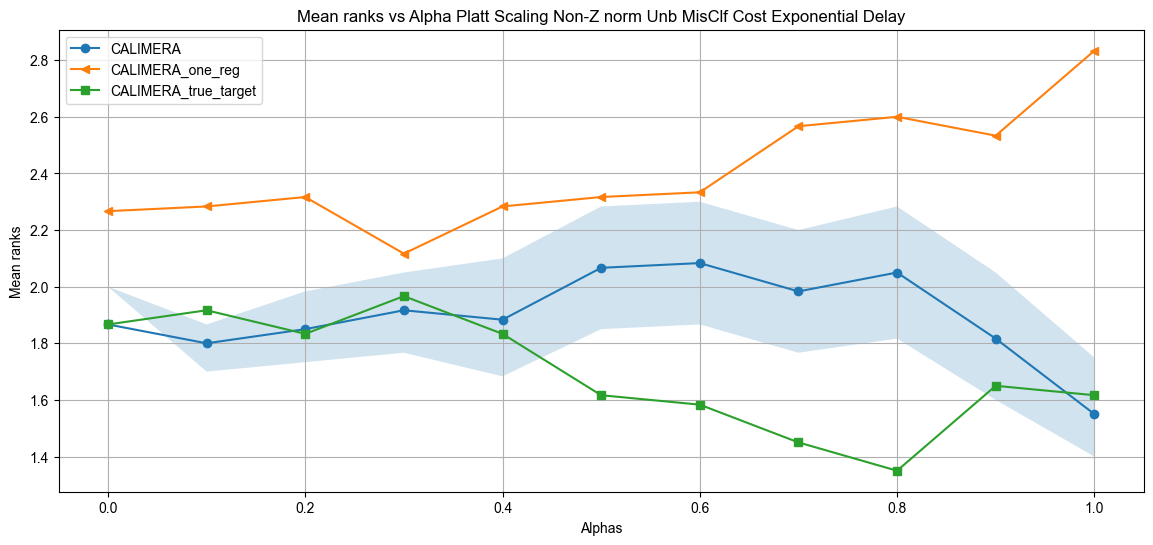

In [84]:
pivot_df = plot_ranks(metrics_one_reg,metrics)

In [85]:
pivot_df[pivot_df['Alpha']=='0.8']

Trigger,Alpha,Dataset,CALIMERA,CALIMERA_eps,CALIMERA_one_reg
240,0.8,AcousticContaminationMadrid_nmv,0.302801,0.232633,0.254307
241,0.8,AluminiumConcentration,0.306004,0.319608,0.316644
242,0.8,BME,0.301417,0.306625,0.345719
243,0.8,BitcoinSentiment,0.250833,0.200333,0.203667
244,0.8,ChilledWaterPredictor,0.282057,0.235102,0.254270
245,0.8,Chinatown,0.036516,0.033989,0.047959
246,0.8,Crop,0.342328,0.326026,0.370769
247,0.8,DhakaHourlyAirQuality,0.074275,0.062614,0.069498
248,0.8,DodgerLoopDay,0.585000,0.547873,0.641823
249,0.8,EOGVerticalSignal,0.538255,0.548406,0.735315


### no flattening

In [86]:
json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\metrics_all_non_z_norm.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    metrics = json.load(file)


json_file_path = 'C:\\Users\\WTHK0243\\OneDrive - orange.com\\Bureau\\ml_edm\\src\\ml_edm\\tests\\metrics_target_flatten_one_reg_val_model_selection.json'

# Load the JSON data
with open(json_file_path, 'r') as file:
    metrics_one_reg = json.load(file)

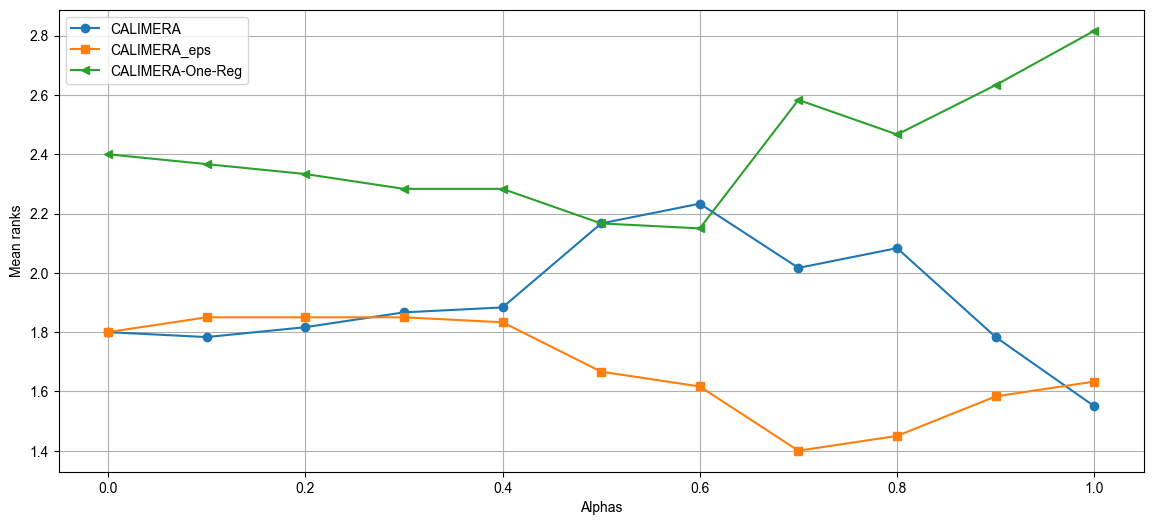

In [87]:
pivot_df = plot_ranks_eps(metrics_one_reg,metrics)